# Multivariate Regular Variation Bias Correction

A notebook exploring the idea of doing a bias correction for the extremal survival function.

## Background

A lingering problem we have been facing is asymptotic undercoverage of our confidence tubes constructed using the extremal survival function. In some simulations last Spring, we were able to isolate estimation of the isoline as one of the drivers behind poor coverage.

As a short recap, if we define our tubes as:

$$
\begin{align}
\hat{R}_{\pmb{X}}^{\alpha}(p) := \{\pmb{x} \in \mathbb{R}^{2}: c_{\alpha}^{-} \leq \hat{\bar{F}}(\pmb{x}) - p \leq c_{\alpha}^{+} \}
\end{align}
$$

where $\hat{c}_{\alpha}^{-} = F_{W^{-}}^{-1}(\alpha/2), \hat{c}_{\alpha}^{+} = F_{W^{+}}^{-1}(1-\alpha/2)$, where

$$
\begin{align}
W^{+} := \sup_{\pmb{x} \in \ell_{\pmb{X}}(\pmb{x})} \hat{\bar{F}}_{\pmb{X}}(\pmb{x}) - p \\
W^{-} := \inf_{\pmb{x} \in \ell_{\pmb{X}}(\pmb{x})} \hat{\bar{F}}_{\pmb{X}}(\pmb{x}) - p
\end{align}
$$

As usual, the issue is we don't know $\ell_{\pmb{X}}(p)$, so we plug in an estimate and use the non-parametric bootstrap to generate draws from the distribution of $W^{+}$, $W^{-}$ conditional on the sample. So, everything hinges on two things occurring: (1) the estimate of the isoline is "good" and (2) the nonparametric bootstrap estimator well-approximates the estimand.

When using the empirical survival function, the results are wonderful. We never experience any undercoverage. In fact, we are only ever overcovered with very small $p$. However, everything crashes and burns when we use the extremal survival function to estimate the isoline.

What is so different? My hunch is that it's because our estimator of the extremal survival function is biased, making our isoline estimates biased. My supporting evidence:
1. We did simulations showing that, when we used the actual isoline instead of an estimate, our $c$'s were no longer skewing too low as sample size increased.
2. In the same simulations, using the actual data distribution to generate draws instead of the non-parametric bootstrap yielded undercoverage even still, so it's not a bootstrap issue.
3. Even when doing sample splitting, we see increased variance and so increased coverage, but it eventually goes down, especially in the asymmetric case.

I think taking this altogether suggests that the bias in the isoline estimation is the issue. If our extremal survival function estimates are biased downward, say, then our isoline estimate is biased in the SE direction. Estimating the survival function on a nonparametric bootstrap draw, the survival function evaluated over our estimate will still be somewhat close to $p$ by way of the bias (this is only getting at the variance)! And so our worst-case differences will be closer to $0$ than we would like. Then when it comes time to drawing the tube around our estimated isoline, we've drawn a tube that accounts for variance but no bias. We can play games where we try to push out how far we are looking in the tail to make that variance swamp the bias, but it isn't a winning strategy in general.

The empirical survival function works so well because that estimator is unbiased. A solution is to account for the bias by blowing up the region over which we evaluate the worst case differences between the survival function and $p$, where the size of the region is large enough to account for the worst case bias. This worst case bias would be estimated. In this way, when running through our procedure we aren't just evaluating a biased estimator over a biased estimate of a level set, but now a biased estimator over a larger region that hopefully includes more points on the "de-biased" isoline, inflating the distribution of worst case differences.

In this notebook, I explore:
1. The bias in isoline estimation and how it manifests for different $n$ and $\gamma$
2. Ways in which we can build in a "bias-correction" into the region, first by assuming we know the exact bias, and then gradually peeling back our assumptions.

In [2]:
library(mvtnorm)
library(readr)
library(ggplot2)
library(dplyr)
library(tidyr)

source('~/isolines_uq/scripts/R/confidence_regions/modules/distributionIsolines.R')
source('~/isolines_uq/scripts/R/confidence_regions/modules/utils.R')
source('~/isolines_uq/scripts/R/confidence_regions/modules/confidenceRegions.R')


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.8-40. For overview type 'help("mgcv-package")'.


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count




In [2]:
samp_func <- loadSamplingFunction('bivt')

## Bias in Isoline Estimation

### Empirical Estimation

In [10]:
n_iter <- 200
n <- 10000
p <- 5/n

In [25]:
isoline <- drawIsoline('bivt', 200, c(100,100), c(-2,-2), p)

In [29]:
plt <- ggplot()

for (i in 1:n_iter) {
    
    dat <- samp_func(n)
    isoline_emp_estimate <- drawEmpiricalIsoline(dat, 200, c(-2,-2), p)
    plt <- plt + geom_point(data=isoline_emp_estimate, aes(x=X1, y=X2), color='blue', alpha=0.1)

}

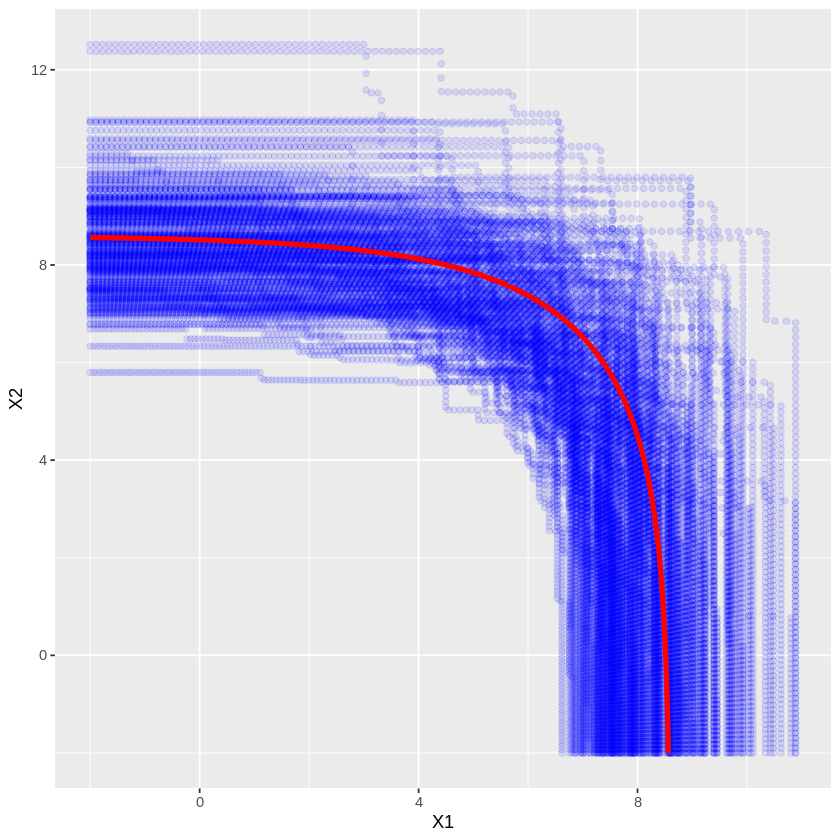

In [30]:
plt + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5)

### Extremal Estimation

In [44]:
xi <- 1/4
n <- 10000
dat <- samp_func(n)
p <- 5/n
n_coords <- 200
grid_lbs <- c(-2,-2)

In [49]:
plt1 <- ggplot()
plt2 <- ggplot()
plt3 <- ggplot()

for (i in 1:n_iter) {
    
    dat <- samp_func(n)
    isoline_ext_estimate1 <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 1/2, xi)
    isoline_ext_estimate2 <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 2/3, xi)
    isoline_ext_estimate3 <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 3/4, xi)
    plt1 <- plt1 + geom_point(data=isoline_ext_estimate1, aes(x=X1, y=X2), color='blue', alpha=0.1)
    plt2 <- plt2 + geom_point(data=isoline_ext_estimate2, aes(x=X1, y=X2), color='orange', alpha=0.1)
    plt3 <- plt3 + geom_point(data=isoline_ext_estimate3, aes(x=X1, y=X2), color='green', alpha=0.1)
}

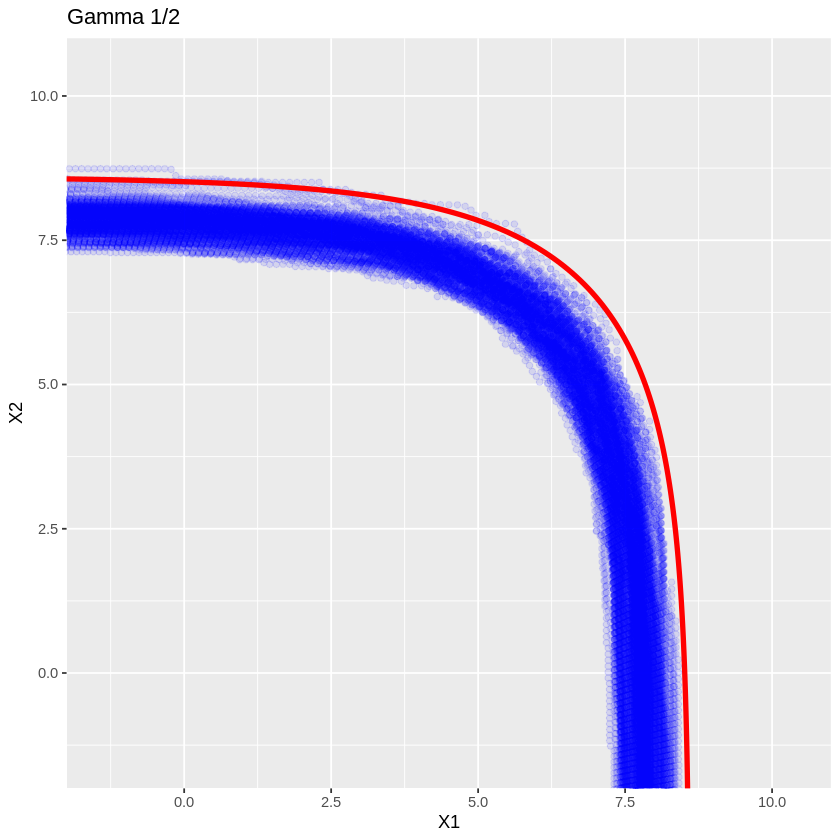

In [51]:
plt1 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,11), ylim=c(-2,11), expand=FALSE) + ggtitle('Gamma 1/2')

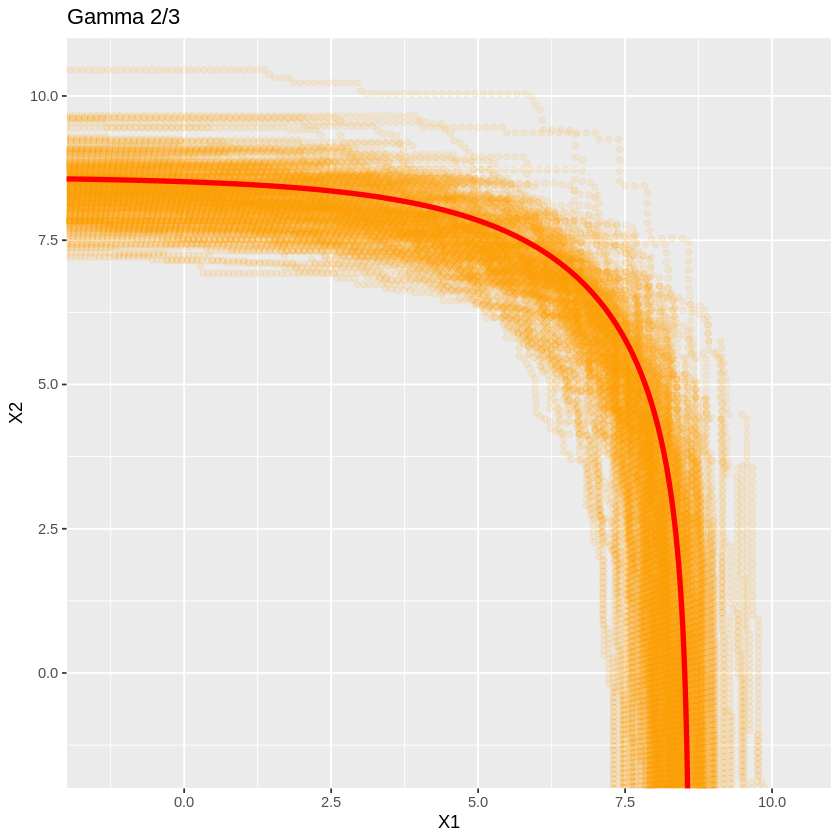

In [52]:
plt2 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,11), ylim=c(-2,11), expand=FALSE) + ggtitle('Gamma 2/3')

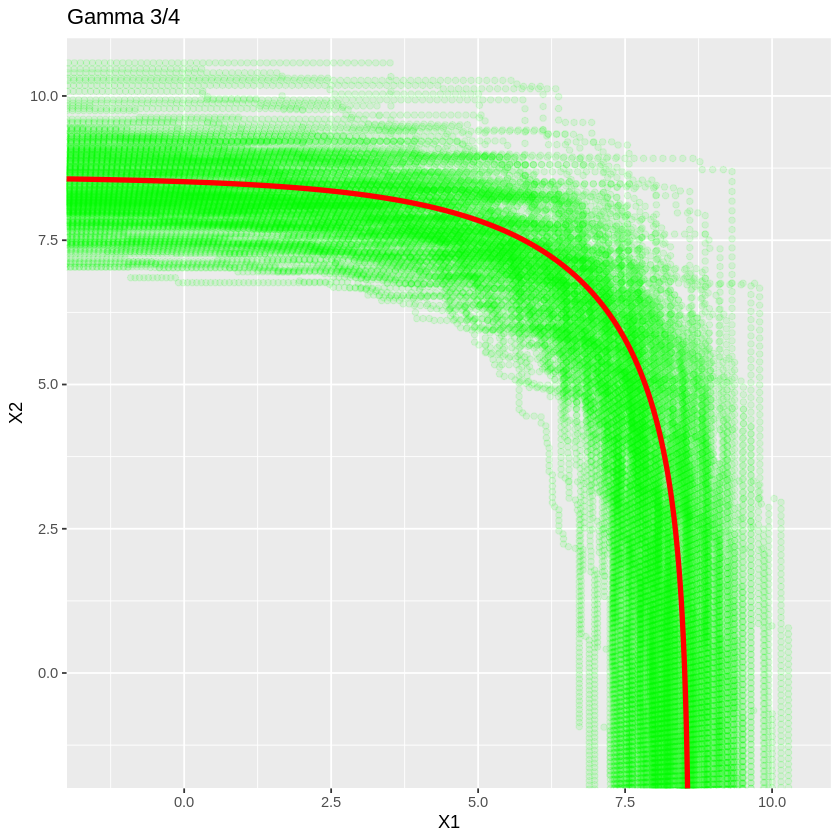

In [53]:
plt3 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,11), ylim=c(-2,11), expand=FALSE) + ggtitle('Gamma 3/4')

I have a hunch that the whole issue is with bias. There's always going to be some bias when projecting, we just need to make sure that the variance always trumps the bias. However, it doesn't really ever seem like, for the order sequences we consider, that the variance trumps the bias for long.. Also, it's worth considering why the empirical tubes are never undercovering, it's always overcovering. For one, the estimator is unbiased..

In [11]:
xi <- 1/4
n <- 50000
n_iter <- 200
dat <- samp_func(n)
p <- 5/n
n_coords <- 200
grid_lbs <- c(-2,-2)

In [10]:
isoline <- drawIsoline('bivt', 200, c(100,100), c(-2,-2), p)

In [8]:
plt1 <- ggplot()
plt2 <- ggplot()
plt3 <- ggplot()

for (i in 1:n_iter) {
    
    dat <- samp_func(n)
    isoline_ext_estimate1 <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 1/2, xi)
    isoline_ext_estimate2 <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 2/3, xi)
    isoline_ext_estimate3 <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 3/4, xi)
    plt1 <- plt1 + geom_point(data=isoline_ext_estimate1, aes(x=X1, y=X2), color='blue', alpha=0.1)
    plt2 <- plt2 + geom_point(data=isoline_ext_estimate2, aes(x=X1, y=X2), color='orange', alpha=0.1)
    plt3 <- plt3 + geom_point(data=isoline_ext_estimate3, aes(x=X1, y=X2), color='green', alpha=0.1)
}

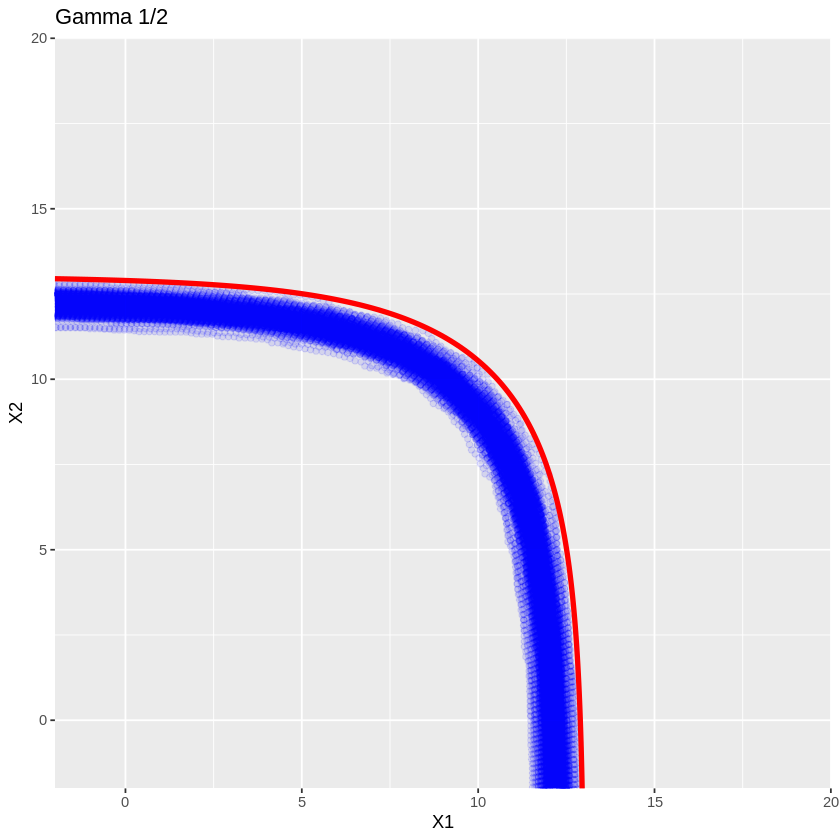

In [12]:
plt1 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,20), ylim=c(-2,20), expand=FALSE) + ggtitle('Gamma 1/2')

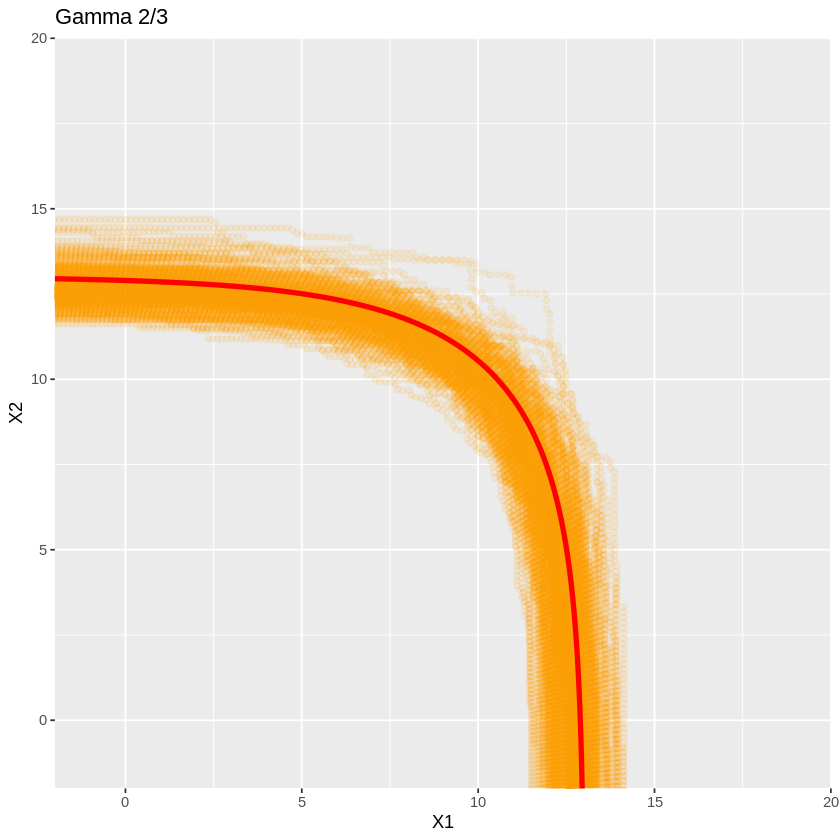

In [13]:
plt2 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,20), ylim=c(-2,20), expand=FALSE) + ggtitle('Gamma 2/3')

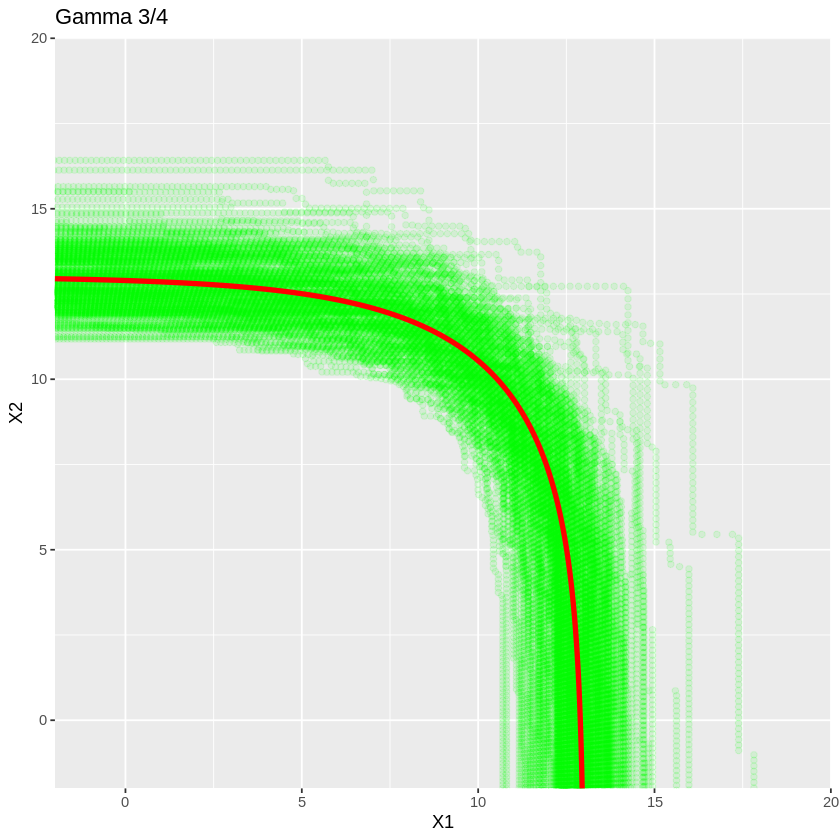

In [14]:
plt3 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,20), ylim=c(-2,20), expand=FALSE) + ggtitle('Gamma 3/4')

## Accounting for Bias

Suppose we we want to capture a $p$-isoline with a confidence tube constructed using the extremal survival function $\hat{\bar{F}}_{\pmb{X}}$. Our usual procedure has been to simulate draws of $W^{+}$ and $W^{-}$ by taking the supremum and infimum over the $p$-level set of the extremal survival function. However, this is a biased estimate: what if we tried to correct or account for that bias somehow? The following experiments show some strategies to correct for this bias.

### Bias Correcting Radii

Let $\theta \in [0,\pi/2]$, and let $\hat{r}_{\theta} = \left\{ r: \hat{\bar{F}}_{ext}(r\cos\theta, r\sin\theta) = p \right\}$. $\hat{r}_{\theta}$ is probably going to be biased for the true $r_{\theta}$, defined as the radius that satisfies $\bar{F}(r_{\theta}\cos\theta, r_{\theta}\sin\theta) = p$. Let $b_{\theta} = \mathbb{E}[\hat{r}_{\theta}] - r_{\theta}$. Then, a reasonable bias-corrected estimator would be:

$$
\begin{align}
\tilde{r}_{\theta} = \hat{r}_{\theta} - b_{\theta}
\end{align}
$$

This is a bias-corrected estimate of the radius on the true $p$-isoline at angle $\theta$. We can repeat this procedure for each $\theta$ to obtain a bias-corrected version of the isoline:

$$
\begin{align}
\hat{\ell}_{\pmb{X}}(p) := \{(\hat{r}_{\theta}\cos\theta, \hat{r}_{\theta}\sin\theta) : \theta \in [0,\pi/2]\} \\
\tilde{\ell}_{\pmb{X}}(p) := \{(\tilde{r}_{\theta}\cos\theta, \tilde{r}_{\theta}\sin\theta) : \theta \in [0,\pi/2]\}
\end{align}
$$

Let's show some visualizations of what this bias correction might look like before moving on to doing some simulations..

In [49]:
xi <- 1/4
n <- 50000
n_iter <- 10
dat <- samp_func(n)
p <- 5/n
n_coords <- 100
grid_lbs <- c(0,0)

isoline <- drawIsoline('bivt', n_coords, c(100,100), c(0,0), p)

thetas <- atan2(isoline[,2], isoline[,1])
r_thetas <- sqrt(isoline[,1]**2 + isoline[,2]**2)

n_monte_carlo <- 1000
r_hat_theta_mat <- matrix(NA, nrow=n_monte_carlo, ncol=length(thetas))

pb <- txtProgressBar(min = 0, max = n_monte_carlo, style = 3)

for (i in 1:n_monte_carlo) {
    dat <- samp_func(n)
    isoline_ext_estimate <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 1/2, xi)
    r_hat_thetas <- sqrt(isoline_ext_estimate[,1]**2 + isoline_ext_estimate[,2]**2)
    r_hat_theta_mat[i,] <- r_hat_thetas
    
    setTxtProgressBar(pb, i)
}

close(pb)

  |======================================================================| 100%


In [50]:
b_thetas <- colMeans(r_hat_theta_mat) - r_thetas

In [54]:
plt1 <- ggplot()

for (i in 1:n_iter) {
    
    dat <- samp_func(n)
    isoline_estimate <- drawExtremeIsoline(dat, p, n_coords, grid_lbs, 1/2, xi)
    r_hats <- sqrt(isoline_estimate[,1]**2 + isoline_estimate[,2]**2)
    thetas <- atan2(isoline_estimate[,2], isoline_estimate[,1])
    r_tildes <- r_hats - b_thetas
    isoline_bc_estimate <- data.frame(X1=r_tildes*cos(thetas), X2=r_tildes*sin(thetas))
    
    plt1 <- plt1 + geom_point(data=isoline_estimate, aes(x=X1, y=X2), color='gray', alpha=0.2)
    plt1 <- plt1 + geom_point(data=isoline_bc_estimate, aes(x=X1, y=X2), color='blue', alpha=0.2)
}

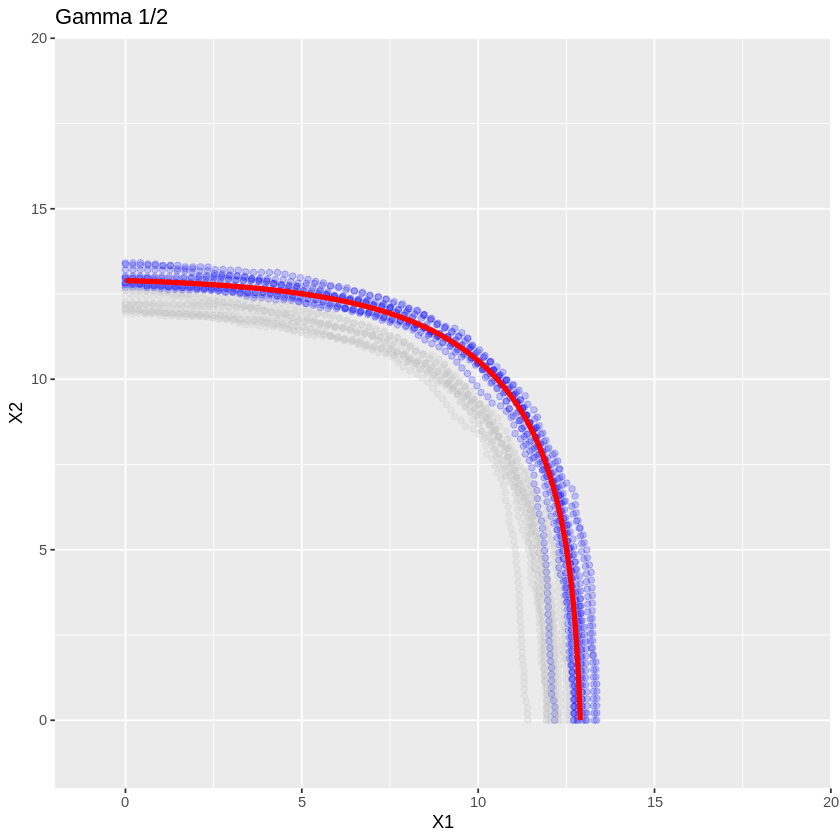

In [55]:
plt1 + geom_line(data=isoline, aes(x=X1, y=X2), color='red', size=1.5) + coord_cartesian(xlim=c(-2,20), ylim=c(-2,20), expand=FALSE) + ggtitle('Gamma 1/2')

Now to show some simulation results. We simulate data from a bivariate t distribution with 4 degrees of freedom, and instead of performing a marginal transformation and building a tube in the transformed space, we simply keep the data as Bivariate t, and assume knowledge of the index of regular variation ($\eta = 4$) and construct our extremal survival function using this knowledge.

+ Simulation Script: `knownindex_oracleline_asymmetric_strategy1.R`
+ Coverage Summary Output: `extremal_coverage_true_radial_bc_no_transform.csv`
+ Confidence Regions Path: `/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.67/no_transform/bivt/`




In [9]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_true_radial_bc_no_transform.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.986,0.989,0
5000,0.01,0.984,0.987,0
10000,0.01,0.992,0.995,0
50000,0.01,0.996,0.999,0
1000,0.05,0.958,0.961,0
5000,0.05,0.960,0.963,0
10000,0.05,0.982,0.985,0
50000,0.05,0.970,0.973,0
1000,0.10,0.922,0.925,0


Let's also look for what our bias correction is for each sample size.

In [15]:
tube1000 <- readRDS('/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.67/no_transform/bivt/n1000/simulation1.RData')
tube5000 <- readRDS('/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.67/no_transform/bivt/n5000/simulation1.RData')
tube10000 <- readRDS('/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.67/no_transform/bivt/n10000/simulation1.RData')
tube50000 <- readRDS('/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.67/no_transform/bivt/n50000/simulation1.RData')

Bias correction definitely does make things a bit better. For reference, let's show what the results look like if we didn't do any bias correction at all.

In [28]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_nobc_notransform.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.964,0.967,0
5000,0.01,0.970,0.973,0
10000,0.01,0.964,0.967,0
50000,0.01,0.982,0.985,0
1000,0.05,0.896,0.900,0
5000,0.05,0.932,0.935,0
10000,0.05,0.916,0.919,0
50000,0.05,0.946,0.949,0
1000,0.10,0.850,0.854,0


It's interesting that the bias correction leads to overcoverage, relative to the uncorrected procedure. Let's investigate what happens when we have $\gamma = 1/2$, meaning that we make the regular variation assumption much sooner into the tail, leading to greater bias and less variance. 

The following are the bias corrected results.

In [3]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_true_radial_bc_no_transform_gamma_0.5.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.996,0.999,0
5000,0.01,0.996,0.999,0
10000,0.01,0.996,0.999,0
50000,0.01,0.994,0.997,0
1000,0.05,0.982,0.985,0
5000,0.05,0.982,0.985,0
10000,0.05,0.986,0.989,0
50000,0.05,0.980,0.983,0
1000,0.10,0.974,0.977,0


And the following are the uncorrected results.

In [4]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_nobc_notransform.csv'
res <- read_csv(path, show_col_types=FALSE)
res <- res[6001:12000,]
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.720,0.724,0
5000,0.01,0.442,0.446,0
10000,0.01,0.334,0.338,0
50000,0.01,0.166,0.170,0
1000,0.05,0.516,0.520,0
5000,0.05,0.240,0.244,0
10000,0.05,0.166,0.170,0
50000,0.05,0.079,0.082,0
1000,0.10,0.424,0.428,0


Ok, here it is! The uncorrected procedure fails when we intentionally make our estimator have more bias and less variance, while the corrected procedure maintains some slight overcoverage. It's interesting that it maintains overcoverage even with a more biased estimator. This tells us that there's something inherent about having an unbiased estimator of the isoline that produces overcoverage, while for the empirical distribution, we get asymptotically the correct coverage much more quickly..

To check our assumptions that our bias-corrected estimators are actually unbiased, lets do some Monte Carlo simulations.

In [37]:
# biases already computed for each n, stored in the confidence tube simulation results
# let's grab these first so we don't have to recompute
# NOTE: these biases were computed with 2000 Monte Carlo Simulations
bc_gamma0.67_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.67/no_transform/bivt/'
bias_lst <- vector(mode='list')
bias_lst[['1000']] <- readRDS(paste0(bc_gamma0.67_path, 'n1000/simulation1.RData'))$b_thetas
bias_lst[['5000']] <- readRDS(paste0(bc_gamma0.67_path, 'n5000/simulation1.RData'))$b_thetas
bias_lst[['10000']] <- readRDS(paste0(bc_gamma0.67_path, 'n10000/simulation1.RData'))$b_thetas
bias_lst[['50000']] <- readRDS(paste0(bc_gamma0.67_path, 'n50000/simulation1.RData'))$b_thetas

In [49]:
library(foreach)
library(doSNOW)
library(parallel)

ns <- as.numeric(names(bias_lst))

dist <- 'bivt'
sampling_func <- loadSamplingFunction(dist)
n_coords <- 100
ubs <- c(200, 200)
gamma <- 1/2
lbs <- c(0, 0)
n_monte_carlo <- 10000
gamma <- 2/3
xi <- 1/4

rhat_biases <- vector(mode='list')
rtilde_biases <- vector(mode='list')

cl <- makeCluster(10)
registerDoSNOW(cl)

for (n in ns) {
    cat("\nRunning Monte Carlo simulations for n =", n, "\n")
    
    pn <- function(n) 5/n
    isoline <- drawIsoline(dist=dist, numCoords=n_coords, gridUbs=ubs, gridLbs=lbs, prob=pn(n))
    thetas <- atan2(isoline[,2], isoline[,1])
    r_thetas <- sqrt(isoline[,1]**2 + isoline[,2]**2)

    pb <- txtProgressBar(min = 0, max = n_monte_carlo, style = 3)
    progress <- function(i) setTxtProgressBar(pb, i)
    opts <- list(progress = progress)

    results <- foreach(i = 1:n_monte_carlo, 
                       .combine = 'rbind',
                       .packages = c('mvtnorm', 'matrixStats'),
                       .options.snow = opts) %dopar% {
        
        dat <- sampling_func(n)
        isoline_ext_estimate <- drawExtremeIsoline(dat=dat, p=pn(n), n_coords=n_coords, grid_lbs=lbs, gamma=gamma, xi=xi)
        r_hat_thetas <- sqrt(isoline_ext_estimate[,1]**2 + isoline_ext_estimate[,2]**2)
        r_tilde_thetas <- r_hat_thetas - bias_lst[[as.character(n)]]
        
        c(r_hat_thetas, r_tilde_thetas)
    }

    close(pb)

    n_cols <- length(thetas)
    r_hat_theta_mat <- results[, 1:n_cols]
    r_tilde_theta_mat <- results[, (n_cols + 1):(2 * n_cols)]

    rhat_biases[[as.character(n)]] <- colMeans(r_hat_theta_mat) - r_thetas
    rtilde_biases[[as.character(n)]] <- colMeans(r_tilde_theta_mat) - r_thetas
}

stopCluster(cl)


Running Monte Carlo simulations for n = 1000 
  |======================================================================| 100%

Running Monte Carlo simulations for n = 5000 
  |======================================================================| 100%

Running Monte Carlo simulations for n = 10000 
  |======================================================================| 100%

Running Monte Carlo simulations for n = 50000 
  |======================================================================| 100%


Let's visualize these radial biases.

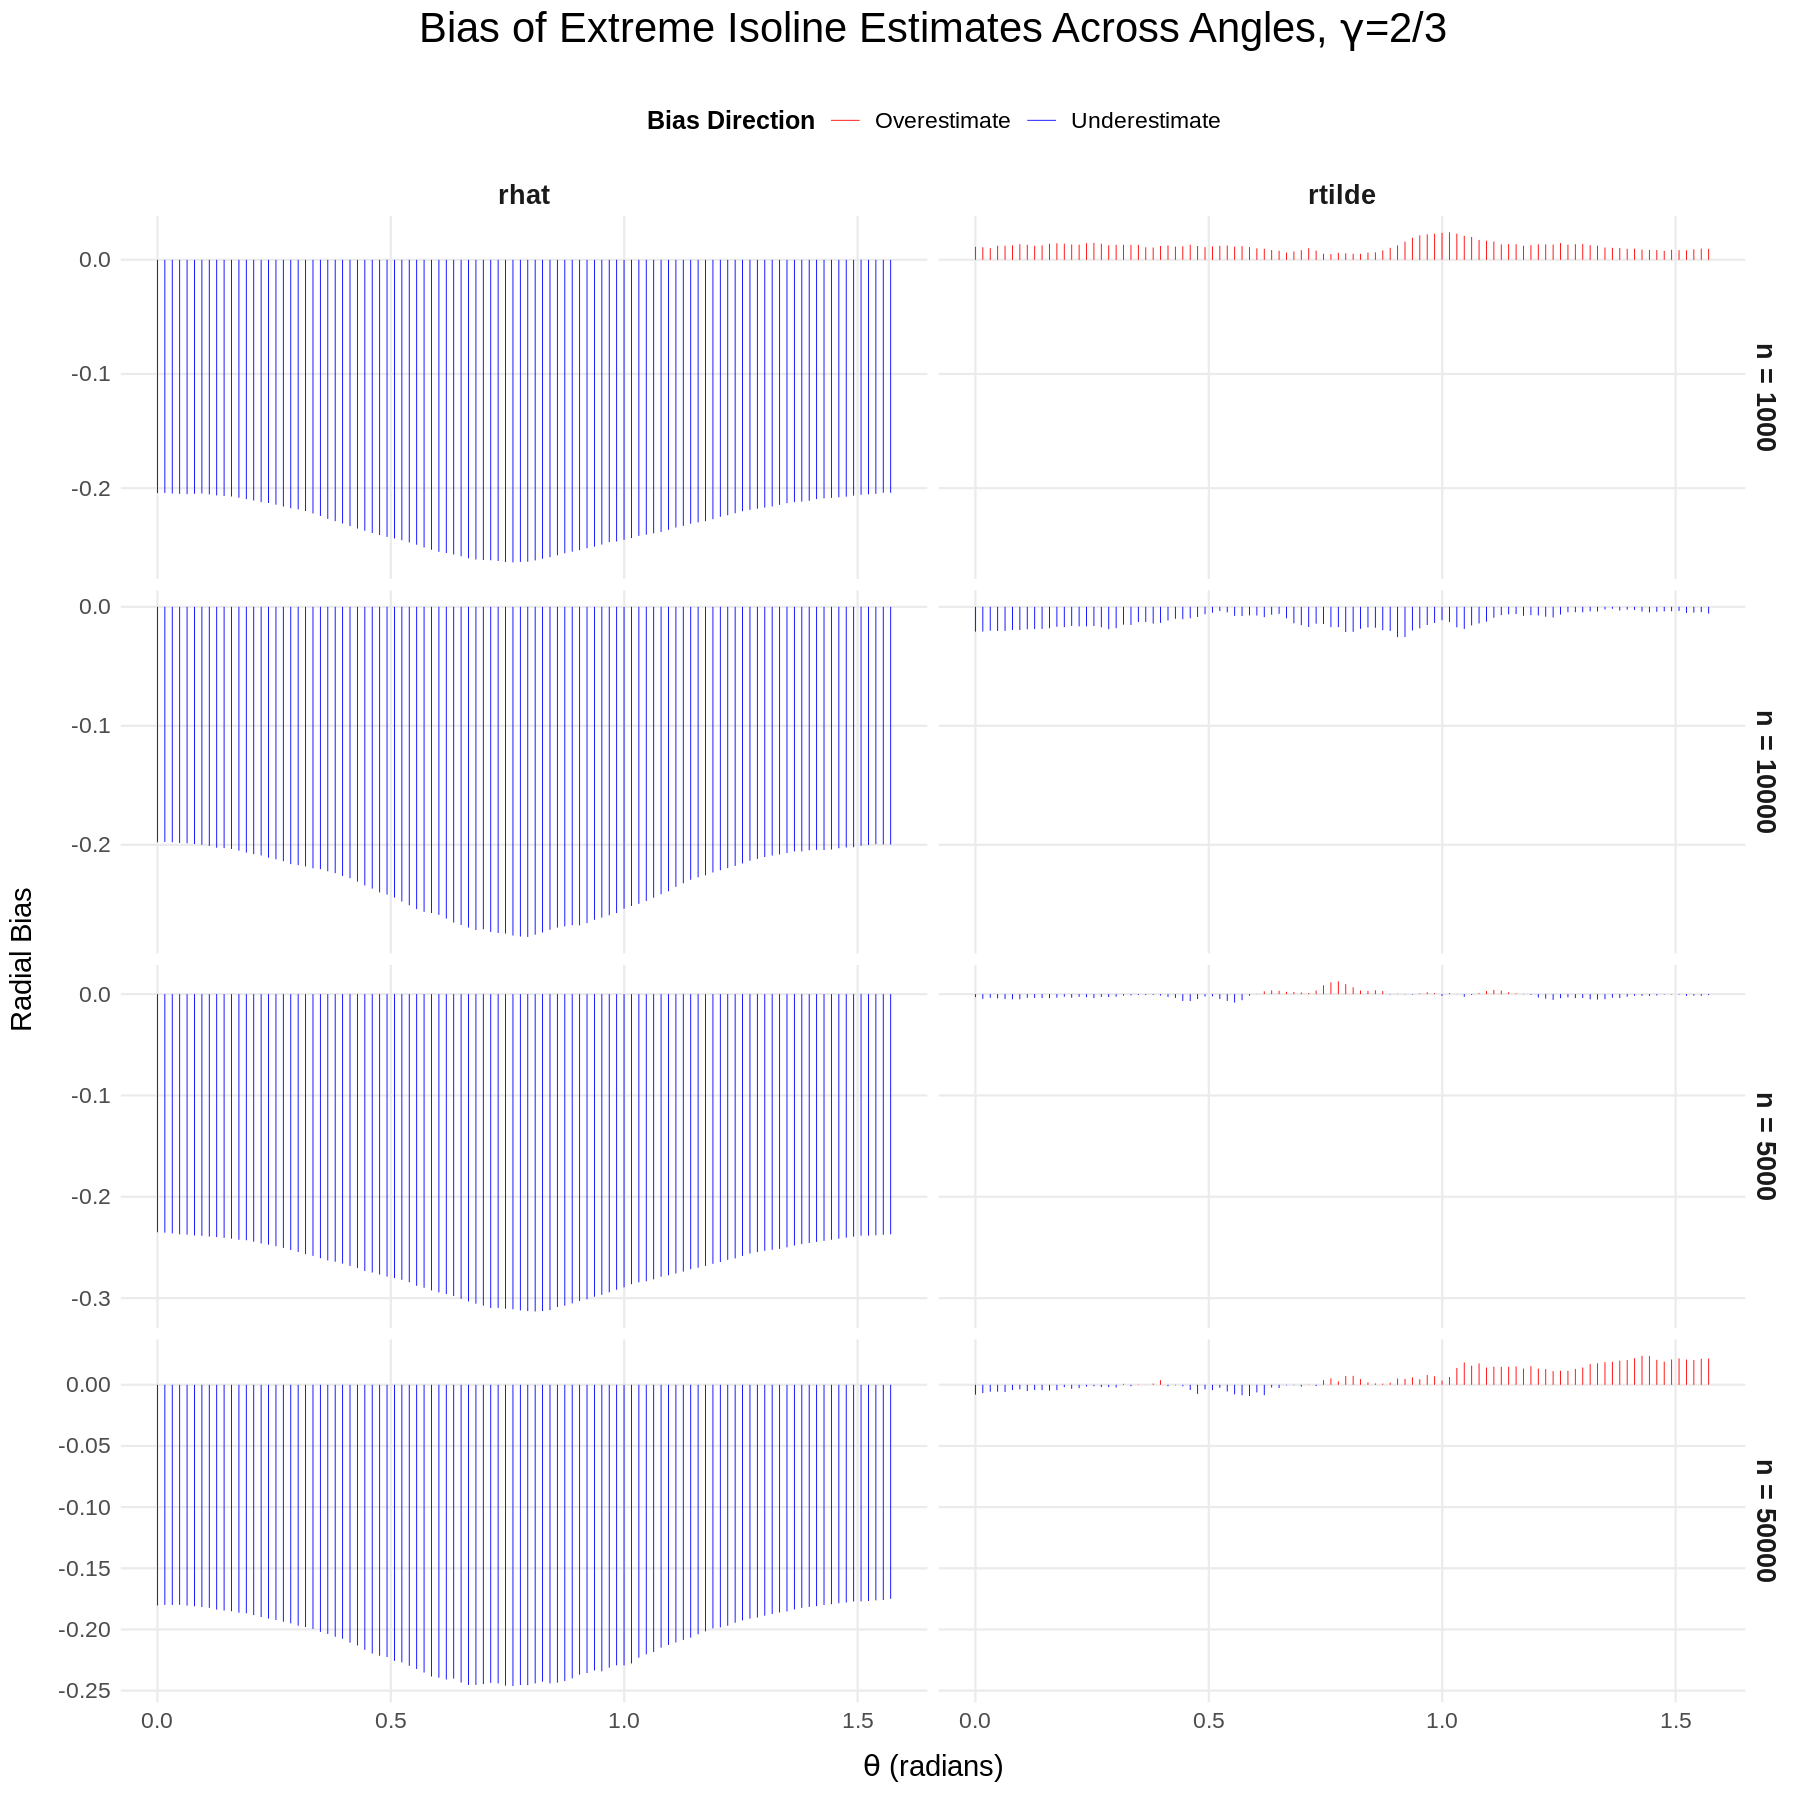

In [86]:
num_ns <- length(ns)
options(repr.plot.width = 12, repr.plot.height = 3 * num_ns, repr.plot.res = 150)

all_plots_data <- list()

for (n_val in ns) {
  n_char <- as.character(n_val)
  
  # Build a temporary dataframe for this specific n
  tmp_data <- data.frame(
    n = n_val, 
    theta = thetas,
    rhat = rhat_biases[[n_char]],
    rtilde = rtilde_biases[[n_char]]
  )
  
  all_plots_data[[n_char]] <- tmp_data
}

# Stack all the individual dataframes
plot_data <- bind_rows(all_plots_data)

# 2. Reshape to long format
tidy_data <- plot_data %>%
  pivot_longer(
    cols = c(rhat, rtilde),
    names_to = "Estimator",
    values_to = "bias"
  ) %>%
  mutate(
    # Create a fill category for positive vs negative bias
    bias_direction = ifelse(bias > 0, "Overestimate", "Underestimate"),
    
    # Format 'n' for the facet labels
    n_label = paste("n =", n)
  )

size_title        <- 20
size_axis_titles  <- 14
size_axis_text    <- 11
size_facet_labels <- 13
size_legend_title <- 12
size_legend_text  <- 11

plt <- ggplot(tidy_data, aes(x = theta, y = bias, color = bias_direction)) +
  
  # Draws the stems
  geom_segment(aes(xend = theta, yend = 0), linewidth = 0.2) + 
  
  scale_color_manual(values = c("Overestimate" = "red", "Underestimate" = "blue")) +
  facet_grid(n_label ~ Estimator, scales = "free_y") +
  
  theme_minimal() +
  theme(
    plot.title   = element_text(size = size_title, face = "bold", hjust = 0.5, margin = margin(b = 15)),
    axis.title.x = element_text(size = size_axis_titles, margin = margin(t = 10)),
    axis.title.y = element_text(size = size_axis_titles, margin = margin(r = 10)),
    axis.text.x  = element_text(size = size_axis_text),
    axis.text.y  = element_text(size = size_axis_text),
    strip.text   = element_text(size = size_facet_labels, face = "bold"),
    legend.title = element_text(size = size_legend_title, face = "bold"),
    legend.text  = element_text(size = size_legend_text),

    legend.position = "top",
    panel.grid.minor = element_blank()
  ) +
  labs(
    title = expression(paste("Bias of Extreme Isoline Estimates Across Angles, ", gamma, "=2/3")),
    x = expression(paste(theta, ' (radians)')),
    y = "Radial Bias",
    color = "Bias Direction"
  )
plt
ggsave(filename = "radial_bias_stem_plot_gamma0.67.png", plot = plt, width = 12, height = 3 * num_ns, dpi = 300)

Let's do this all again, but now for $\gamma = 1/2$.

In [88]:
# biases already computed for each n, stored in the confidence tube simulation results
# let's grab these first so we don't have to recompute
# NOTE: these biases were computed with 2000 Monte Carlo Simulations
bc_gamma0.5_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal_bias_correction/strategy1/gamma0.5/no_transform/bivt/'
bias_lst <- vector(mode='list')
bias_lst[['1000']] <- readRDS(paste0(bc_gamma0.5_path, 'n1000/simulation1.RData'))$b_thetas
bias_lst[['5000']] <- readRDS(paste0(bc_gamma0.5_path, 'n5000/simulation1.RData'))$b_thetas
bias_lst[['10000']] <- readRDS(paste0(bc_gamma0.5_path, 'n10000/simulation1.RData'))$b_thetas
bias_lst[['50000']] <- readRDS(paste0(bc_gamma0.5_path, 'n50000/simulation1.RData'))$b_thetas

In [90]:
library(foreach)
library(doSNOW)
library(parallel)

ns <- as.numeric(names(bias_lst))

dist <- 'bivt'
sampling_func <- loadSamplingFunction(dist)
n_coords <- 100
ubs <- c(200, 200)
gamma <- 1/2
lbs <- c(0, 0)
n_monte_carlo <- 10000
gamma <- 1/2
xi <- 1/4

rhat_biases <- vector(mode='list')
rtilde_biases <- vector(mode='list')

cl <- makeCluster(20)
registerDoSNOW(cl)

for (n in ns) {
    cat("\nRunning Monte Carlo simulations for n =", n, "\n")
    
    pn <- function(n) 5/n
    isoline <- drawIsoline(dist=dist, numCoords=n_coords, gridUbs=ubs, gridLbs=lbs, prob=pn(n))
    thetas <- atan2(isoline[,2], isoline[,1])
    r_thetas <- sqrt(isoline[,1]**2 + isoline[,2]**2)

    pb <- txtProgressBar(min = 0, max = n_monte_carlo, style = 3)
    progress <- function(i) setTxtProgressBar(pb, i)
    opts <- list(progress = progress)

    results <- foreach(i = 1:n_monte_carlo, 
                       .combine = 'rbind',
                       .packages = c('mvtnorm', 'matrixStats'),
                       .options.snow = opts) %dopar% {
        
        dat <- sampling_func(n)
        isoline_ext_estimate <- drawExtremeIsoline(dat=dat, p=pn(n), n_coords=n_coords, grid_lbs=lbs, gamma=gamma, xi=xi)
        r_hat_thetas <- sqrt(isoline_ext_estimate[,1]**2 + isoline_ext_estimate[,2]**2)
        r_tilde_thetas <- r_hat_thetas - bias_lst[[as.character(n)]]
        
        c(r_hat_thetas, r_tilde_thetas)
    }

    close(pb)

    n_cols <- length(thetas)
    r_hat_theta_mat <- results[, 1:n_cols]
    r_tilde_theta_mat <- results[, (n_cols + 1):(2 * n_cols)]

    rhat_biases[[as.character(n)]] <- colMeans(r_hat_theta_mat) - r_thetas
    rtilde_biases[[as.character(n)]] <- colMeans(r_tilde_theta_mat) - r_thetas
}

stopCluster(cl)


Running Monte Carlo simulations for n = 1000 
  |======================================================================| 100%

Running Monte Carlo simulations for n = 5000 
  |======================================================================| 100%

Running Monte Carlo simulations for n = 10000 
  |======================================================================| 100%

Running Monte Carlo simulations for n = 50000 
  |======================================================================| 100%


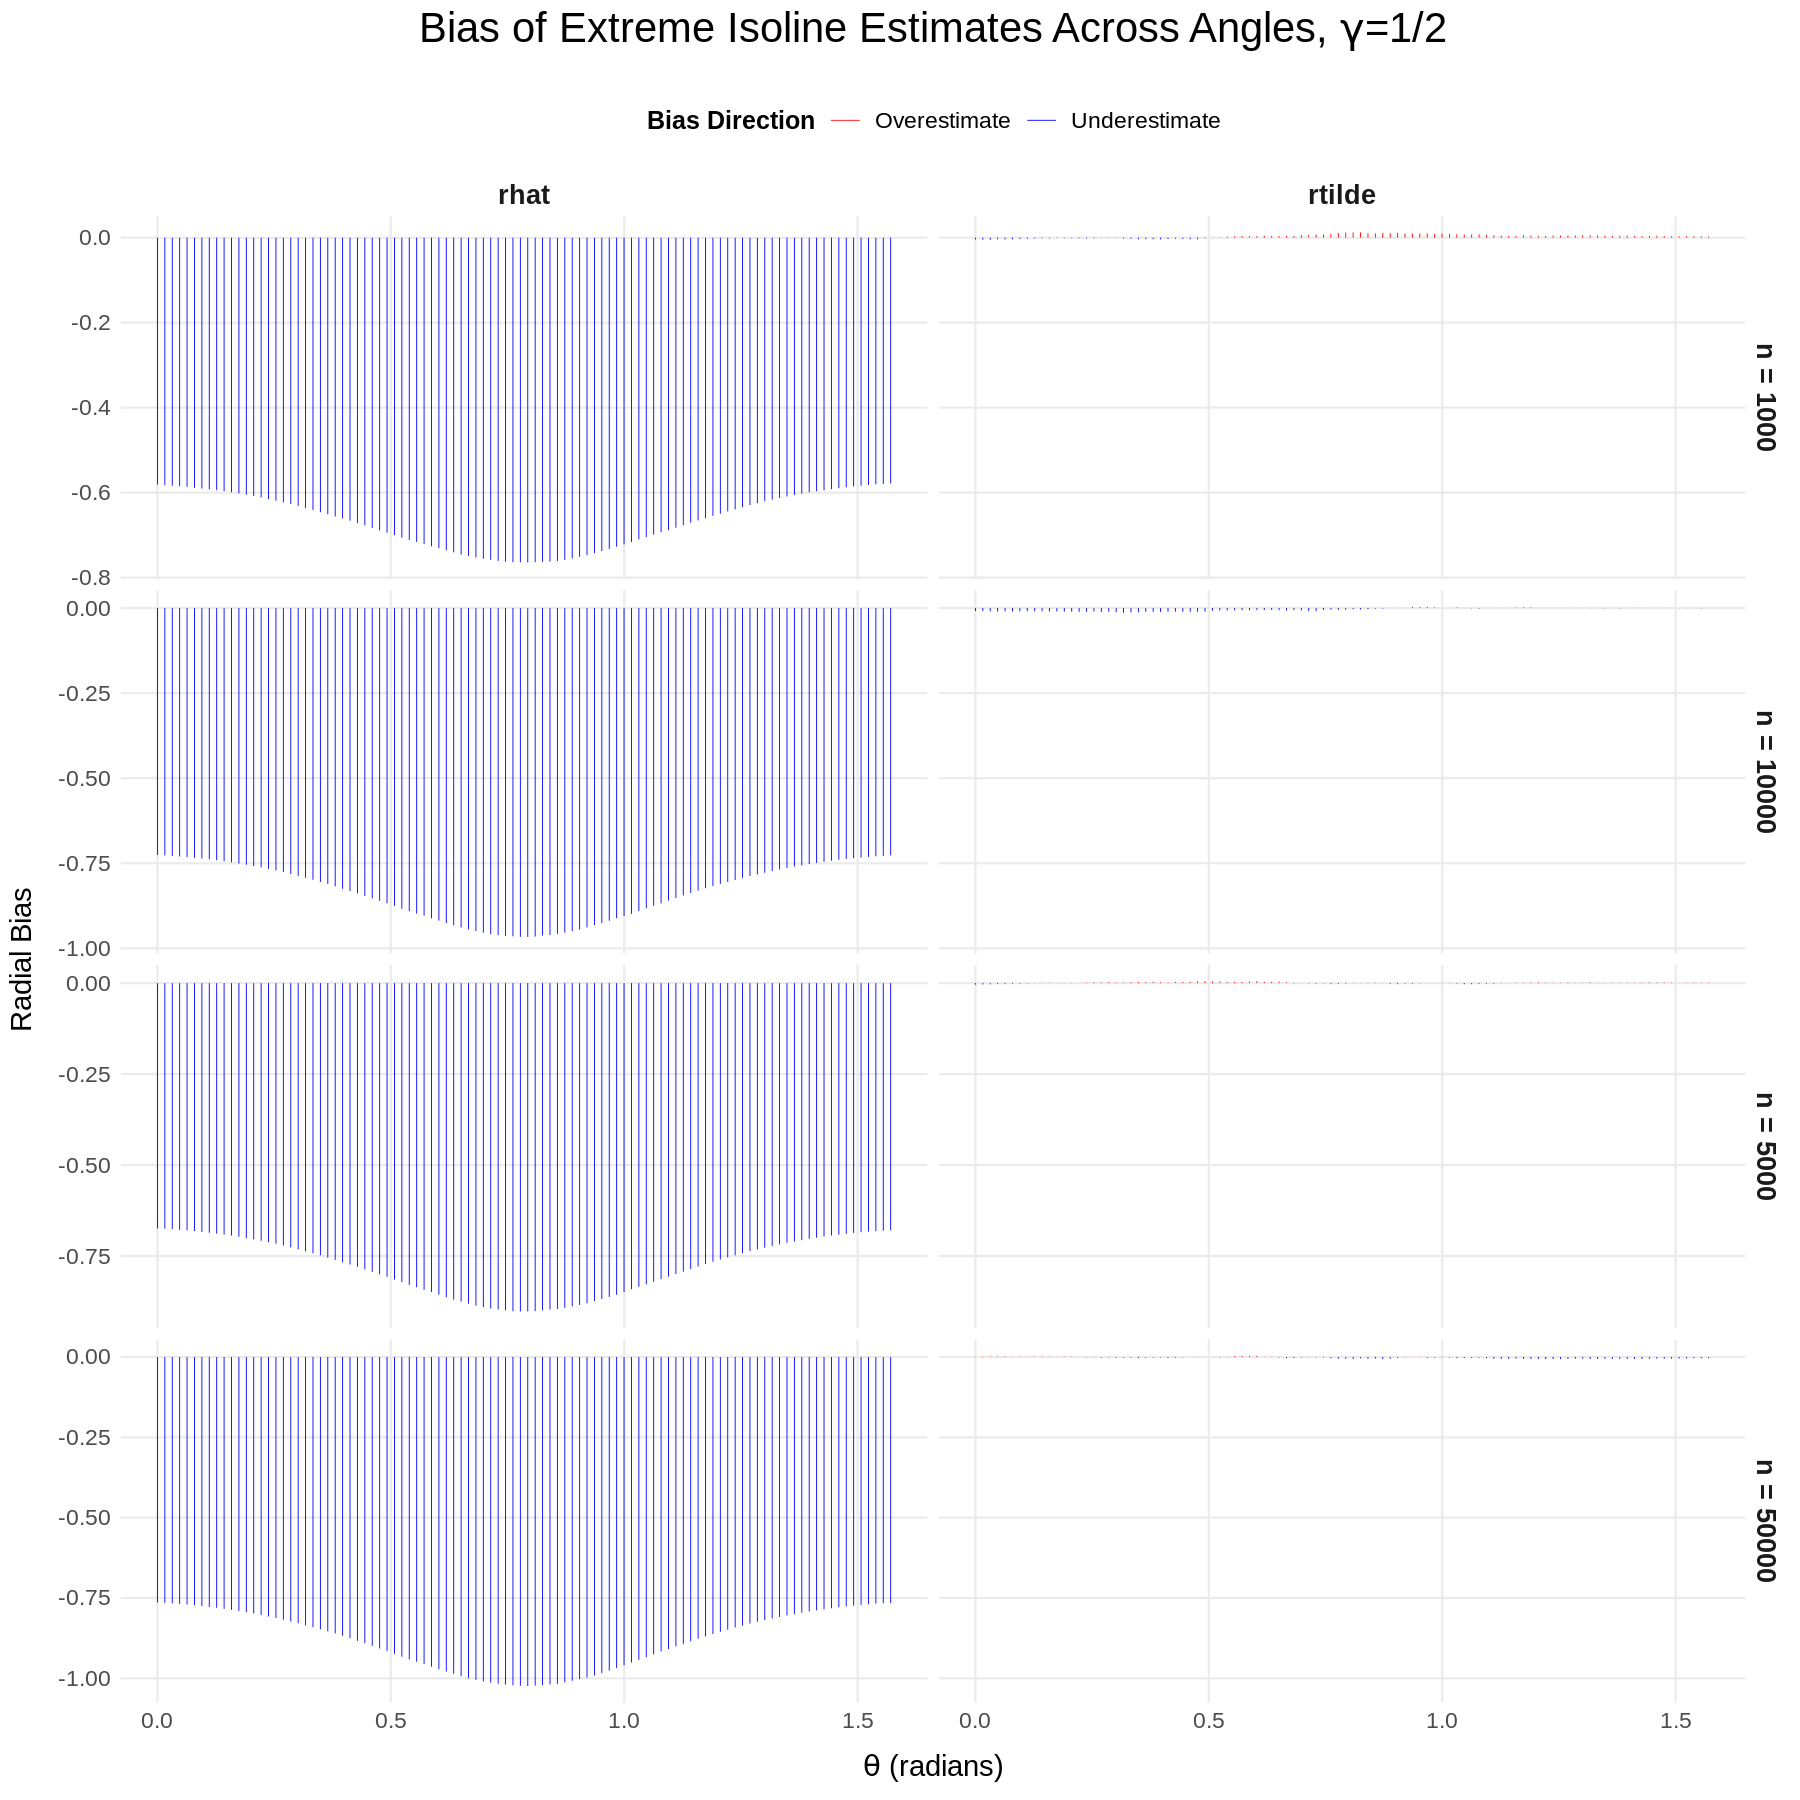

In [91]:
num_ns <- length(ns)
options(repr.plot.width = 12, repr.plot.height = 3 * num_ns, repr.plot.res = 150)

all_plots_data <- list()

for (n_val in ns) {
  n_char <- as.character(n_val)
  
  # Build a temporary dataframe for this specific n
  tmp_data <- data.frame(
    n = n_val, 
    theta = thetas,
    rhat = rhat_biases[[n_char]],
    rtilde = rtilde_biases[[n_char]]
  )
  
  all_plots_data[[n_char]] <- tmp_data
}

# Stack all the individual dataframes
plot_data <- bind_rows(all_plots_data)

# 2. Reshape to long format
tidy_data <- plot_data %>%
  pivot_longer(
    cols = c(rhat, rtilde),
    names_to = "Estimator",
    values_to = "bias"
  ) %>%
  mutate(
    # Create a fill category for positive vs negative bias
    bias_direction = ifelse(bias > 0, "Overestimate", "Underestimate"),
    
    # Format 'n' for the facet labels
    n_label = paste("n =", n)
  )

size_title        <- 20
size_axis_titles  <- 14
size_axis_text    <- 11
size_facet_labels <- 13
size_legend_title <- 12
size_legend_text  <- 11

plt <- ggplot(tidy_data, aes(x = theta, y = bias, color = bias_direction)) +
  
  # Draws the stems
  geom_segment(aes(xend = theta, yend = 0), linewidth = 0.2) + 
  
  scale_color_manual(values = c("Overestimate" = "red", "Underestimate" = "blue")) +
  facet_grid(n_label ~ Estimator, scales = "free_y") +
  
  theme_minimal() +
  theme(
    plot.title   = element_text(size = size_title, face = "bold", hjust = 0.5, margin = margin(b = 15)),
    axis.title.x = element_text(size = size_axis_titles, margin = margin(t = 10)),
    axis.title.y = element_text(size = size_axis_titles, margin = margin(r = 10)),
    axis.text.x  = element_text(size = size_axis_text),
    axis.text.y  = element_text(size = size_axis_text),
    strip.text   = element_text(size = size_facet_labels, face = "bold"),
    legend.title = element_text(size = size_legend_title, face = "bold"),
    legend.text  = element_text(size = size_legend_text),

    legend.position = "top",
    panel.grid.minor = element_blank()
  ) +
  labs(
    title = expression(paste("Bias of Extreme Isoline Estimates Across Angles, ", gamma, "=1/2")),
    x = expression(paste(theta, ' (radians)')),
    y = "Radial Bias",
    color = "Bias Direction"
  )
plt
ggsave(filename = "radial_bias_stem_plot_gamma0.5.png", plot = plt, width = 12, height = 3 * num_ns, dpi = 300)

Ok cool! So it seems like bias correction really does matter! How can we estimate this bias, and correct for it, without access to draws from the distribution we are sampling from, or without knowledge of the true radii? Something that Jon suggested I try is to use the nonparametric bootstrap as a first attempt to estimate the bias. So, instead of computing the bias by getting many monte carlo draws of the isoline and averaging all of the radii together and comparing with the true isoline, our truth is now the estimated isoline for a particular dataset, and then we compare against the average across the bootstrap distribution.

In [4]:
bootstrap_bias_results <- read_csv('/global/homes/j/jbbutler/isolines_uq/outputs/simulations/bias_correction/radial_bias_bootstrap_comparison_gamma0.5_knownindex.csv')

Rows: 100000 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): dist
dbl (8): p, n, sim_id, theta, expected_r_bootstrapworld, true_r_bootstrapwor...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
avg_boot_bias <- bootstrap_bias_results %>% group_by(n, theta) %>% summarize(avg_boot_bias=mean(boot_bias), true_bias=mean(true_bias)) %>% ungroup()

`summarise()` has grouped output by 'n'. You can override using the `.groups`
argument.


In [6]:
df_long <- avg_boot_bias %>%
  pivot_longer(
    cols = c(true_bias, avg_boot_bias),
    names_to = "bias_type",
    values_to = "bias_value"
  ) %>%
  mutate(
    # Format bias_type for clean labels
    bias_type = factor(bias_type, 
                       levels = c("true_bias", "avg_boot_bias"),
                       labels = c("True MC Bias", "Bootstrap Estimated Bias")),
    # Ensure n is a factor so it facets correctly as discrete groups
    n_label = paste0("n = ", n),
    n_label = factor(n_label, levels = paste0("n = ", sort(unique(n))))
  )

p <- ggplot(df_long, aes(x = theta, y = bias_value, fill = bias_type)) +
  geom_bar(stat = "identity", width = 0.04) + 
  # facet_grid creates a matrix: rows are n values, columns are bias types
  facet_grid(n_label ~ bias_type) +
  theme_bw() +
  scale_fill_manual(values = c("True MC Bias" = "#1f77b4", 
                               "Bootstrap Estimated Bias" = "#ff7f0e")) +
  labs(
    title = "Radial Bias Comparison Across Sample Sizes",
    subtitle = "Comparing True Monte Carlo Bias vs. Bootstrap Estimates",
    x = expression("Angle " * theta * " (Radians)"),
    y = "Radial Bias"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 16),
    strip.text = element_text(face = "bold", size = 10),
    strip.background = element_rect(fill = "gray95"),
    panel.spacing = unit(1, "lines") # Adds space between facets for readability
  )

ggsave("radial_bias_comparison_plot.png", plot = p, width = 6, height = 8, dpi = 300)

Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”


The bootstrap is not capturing the bias, at all! Something we can try is this idea of second-order MRV. As it turns out, there's also a limit relation that governs how the difference between the survival function and the limiting measure behaves. This is referred to as second order MRV. It involves another parameter $\rho$. Below, I do an oracle comparison to see how this SOMRV procedure can, with all relevant knowledge, capture the true bias.

In [8]:
somrv_bias_results <- read_csv('/global/homes/j/jbbutler/isolines_uq/outputs/simulations/bias_correction/somrv_simulation1.csv')

Rows: 200 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): dist
dbl (4): n, theta, true_bias, somrv_bias_correction

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning mess

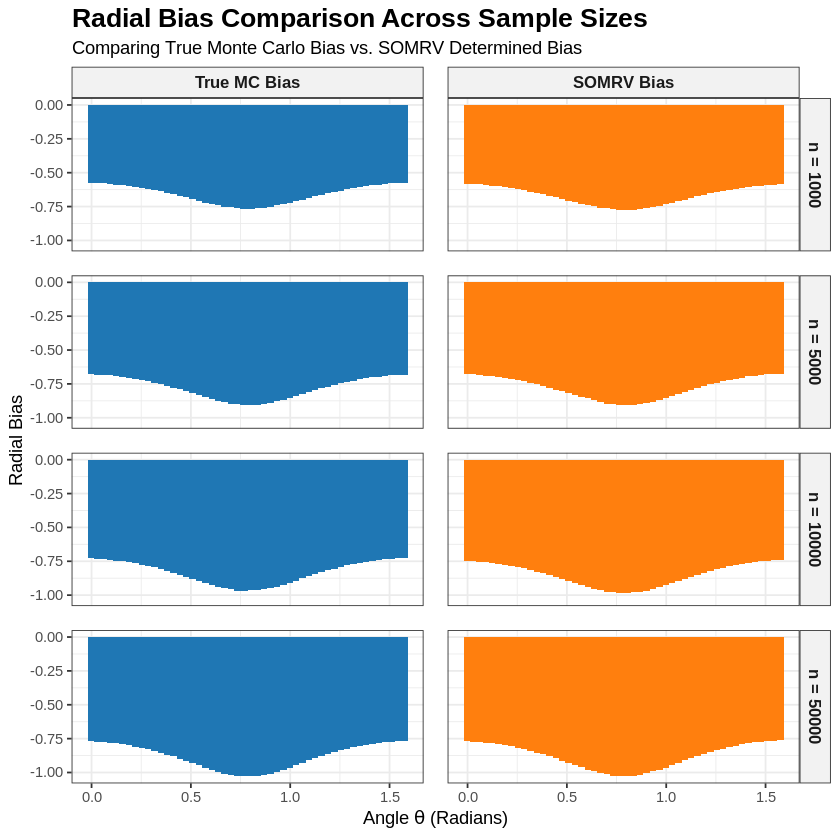

In [10]:
df_long <- somrv_bias_results %>%
  pivot_longer(
    cols = c(true_bias, somrv_bias_correction),
    names_to = "bias_type",
    values_to = "bias_value"
  ) %>%
  mutate(
    # Format bias_type for clean labels
    bias_type = factor(bias_type, 
                       levels = c("true_bias", "somrv_bias_correction"),
                       labels = c("True MC Bias", "SOMRV Bias")),
    # Ensure n is a factor so it facets correctly as discrete groups
    n_label = paste0("n = ", n),
    n_label = factor(n_label, levels = paste0("n = ", sort(unique(n))))
  )

p <- ggplot(df_long, aes(x = theta, y = bias_value, fill = bias_type)) +
  geom_bar(stat = "identity", width = 0.04) + 
  # facet_grid creates a matrix: rows are n values, columns are bias types
  facet_grid(n_label ~ bias_type) +
  theme_bw() +
  scale_fill_manual(values = c("True MC Bias" = "#1f77b4", 
                               "SOMRV Bias" = "#ff7f0e")) +
  labs(
    title = "Radial Bias Comparison Across Sample Sizes",
    subtitle = "Comparing True Monte Carlo Bias vs. SOMRV Determined Bias",
    x = expression("Angle " * theta * " (Radians)"),
    y = "Radial Bias"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 16),
    strip.text = element_text(face = "bold", size = 10),
    strip.background = element_rect(fill = "gray95"),
    panel.spacing = unit(1, "lines") # Adds space between facets for readability
  )
p
ggsave("true_radial_bias_comparison_plot.png", plot = p, width = 6, height = 8, dpi = 300)

In [16]:
somrv_bootstrap_bias_results <- read_csv('/global/homes/j/jbbutler/isolines_uq/outputs/simulations/bias_correction/somrv_simulation2.csv')

Rows: 100000 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): dist
dbl (7): p, n, sim_id, theta, true_bias, somrv_bias_est, in_sample_bias_est

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [17]:
avg_somrv_bias <- somrv_bootstrap_bias_results %>% group_by(n, theta) %>% summarize(avg_somrv_bias=mean(somrv_bias_est), true_bias=mean(true_bias)) %>% ungroup()

`summarise()` has grouped output by 'n'. You can override using the `.groups`
argument.


Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning mess

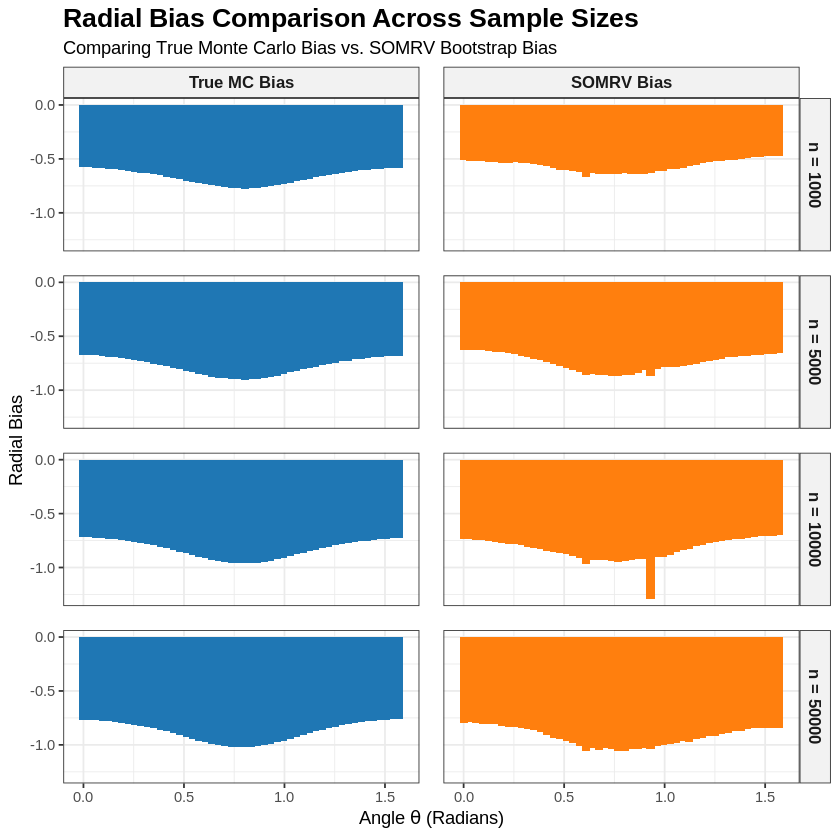

In [14]:
df_long <- avg_somrv_bias %>%
  pivot_longer(
    cols = c(true_bias, avg_somrv_bias),
    names_to = "bias_type",
    values_to = "bias_value"
  ) %>%
  mutate(
    # Format bias_type for clean labels
    bias_type = factor(bias_type, 
                       levels = c("true_bias", "avg_somrv_bias"),
                       labels = c("True MC Bias", "SOMRV Bias")),
    # Ensure n is a factor so it facets correctly as discrete groups
    n_label = paste0("n = ", n),
    n_label = factor(n_label, levels = paste0("n = ", sort(unique(n))))
  )

p <- ggplot(df_long, aes(x = theta, y = bias_value, fill = bias_type)) +
  geom_bar(stat = "identity", width = 0.04) + 
  # facet_grid creates a matrix: rows are n values, columns are bias types
  facet_grid(n_label ~ bias_type) +
  theme_bw() +
  scale_fill_manual(values = c("True MC Bias" = "#1f77b4", 
                               "SOMRV Bias" = "#ff7f0e")) +
  labs(
    title = "Radial Bias Comparison Across Sample Sizes",
    subtitle = "Comparing True Monte Carlo Bias vs. SOMRV Bootstrap Bias",
    x = expression("Angle " * theta * " (Radians)"),
    y = "Radial Bias"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 16),
    strip.text = element_text(face = "bold", size = 10),
    strip.background = element_rect(fill = "gray95"),
    panel.spacing = unit(1, "lines") # Adds space between facets for readability
  )
p
ggsave("bootstrap_somrv_radial_bias.png", plot = p, width = 6, height = 8, dpi = 300)

This was with $\gamma_{1} = 1/2$ and $\gamma_{2} = 2/3$. Ok, it seems like it does a pretty good job!! We're gonna have to explore this a bit more.

In [3]:
somrv_bootstrap_xi_estim <- read_csv('/global/homes/j/jbbutler/isolines_uq/outputs/simulations/bias_correction/somrv_simulation3_nobootxi.csv')

Rows: 100000 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): dist
dbl (8): p, n, sim_id, theta, true_bias, somrv_bias_est, in_sample_bias_est,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
avg_somrv_bias <- somrv_bootstrap_xi_estim %>% group_by(n, theta) %>% summarize(avg_somrv_bias=mean(somrv_bias_est), true_bias=mean(true_bias)) %>% ungroup()

`summarise()` has grouped output by 'n'. You can override using the `.groups`
argument.


Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”


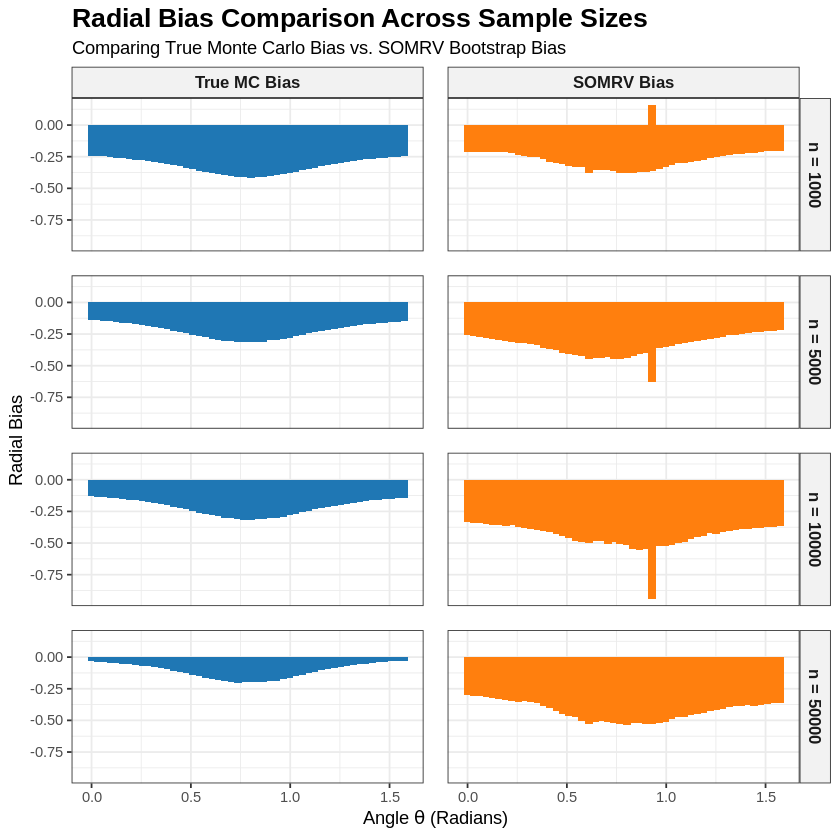

In [5]:
df_long <- avg_somrv_bias %>%
  pivot_longer(
    cols = c(true_bias, avg_somrv_bias),
    names_to = "bias_type",
    values_to = "bias_value"
  ) %>%
  mutate(
    # Format bias_type for clean labels
    bias_type = factor(bias_type, 
                       levels = c("true_bias", "avg_somrv_bias"),
                       labels = c("True MC Bias", "SOMRV Bias")),
    # Ensure n is a factor so it facets correctly as discrete groups
    n_label = paste0("n = ", n),
    n_label = factor(n_label, levels = paste0("n = ", sort(unique(n))))
  )

p <- ggplot(df_long, aes(x = theta, y = bias_value, fill = bias_type)) +
  geom_bar(stat = "identity", width = 0.04) + 
  # facet_grid creates a matrix: rows are n values, columns are bias types
  facet_grid(n_label ~ bias_type) +
  theme_bw() +
  scale_fill_manual(values = c("True MC Bias" = "#1f77b4", 
                               "SOMRV Bias" = "#ff7f0e")) +
  labs(
    title = "Radial Bias Comparison Across Sample Sizes",
    subtitle = "Comparing True Monte Carlo Bias vs. SOMRV Bootstrap Bias",
    x = expression("Angle " * theta * " (Radians)"),
    y = "Radial Bias"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold", size = 16),
    strip.text = element_text(face = "bold", size = 10),
    strip.background = element_rect(fill = "gray95"),
    panel.spacing = unit(1, "lines") # Adds space between facets for readability
  )
p
#ggsave("bootstrap_somrv_radial_bias.png", plot = p, width = 6, height = 8, dpi = 300)

`summarise()` has grouped output by 'n'. You can override using the `.groups`
argument.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


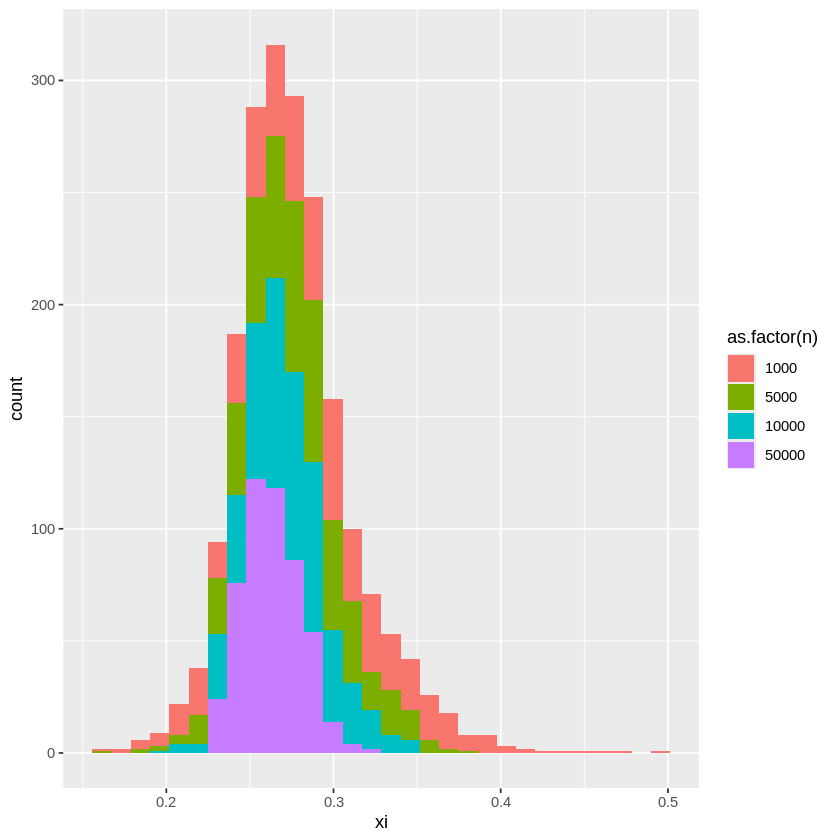

In [6]:
xi_vals <- somrv_bootstrap_xi_estim %>% group_by(n, sim_id) %>% summarize(xi=mean(xi_hat)) %>% ungroup()
ggplot() + geom_histogram(data=xi_vals, aes(x=xi, fill=as.factor(n)))

Interesting. So once we plug in an estimator for $\xi$ by way of the Hill Estimator, we have that our estimator's true radial biases no longer match with those from the second order MRV correction. It seems like the bias of the Hill estimator helps reduce this overall bias, since it helps us overshoot. However, it seems like because it also helps us overshoot for q1 to q2, thus reducing that overall bias, but then the second order MRV $M$ term then gets overshot with a higher $\xi$, they balance out and the bias stays a bit high. Jon and I discussed using a bias-corrected estimator for $\xi$ from [here](https://ceaul.org/wp-content/uploads/2020/04/2004-WP-NC-18(C+G+P).pdf). Below, we implement this estimator, where the only thing we still treat as an oracle is $\rho$ for use in the SOMRV. We'll probably still end up taking $\rho \to 0$, but this will help us immediately see if bias-correcting the hill estimator helps!

In [91]:
somrv_results <- read_csv('/global/homes/j/jbbutler/isolines_uq/outputs/simulations/bias_correction/somrv_simulation_CH_xi_truerho.csv')

Rows: 100000 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): dist
dbl (11): p, n, sim_id, theta, true_bias, somrv_bias_est, in_sample_bias_est...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [93]:
diagnostics <- somrv_results %>% group_by(sim_id, n) %>% summarize(beta_hat=mean(beta_hat), rho_hat=mean(rho_hat), xi_hat_hill=mean(xi_hat_hill), xi_hat_ch=mean(xi_hat_ch)) %>% ungroup()

`summarise()` has grouped output by 'sim_id'. You can override using the
`.groups` argument.


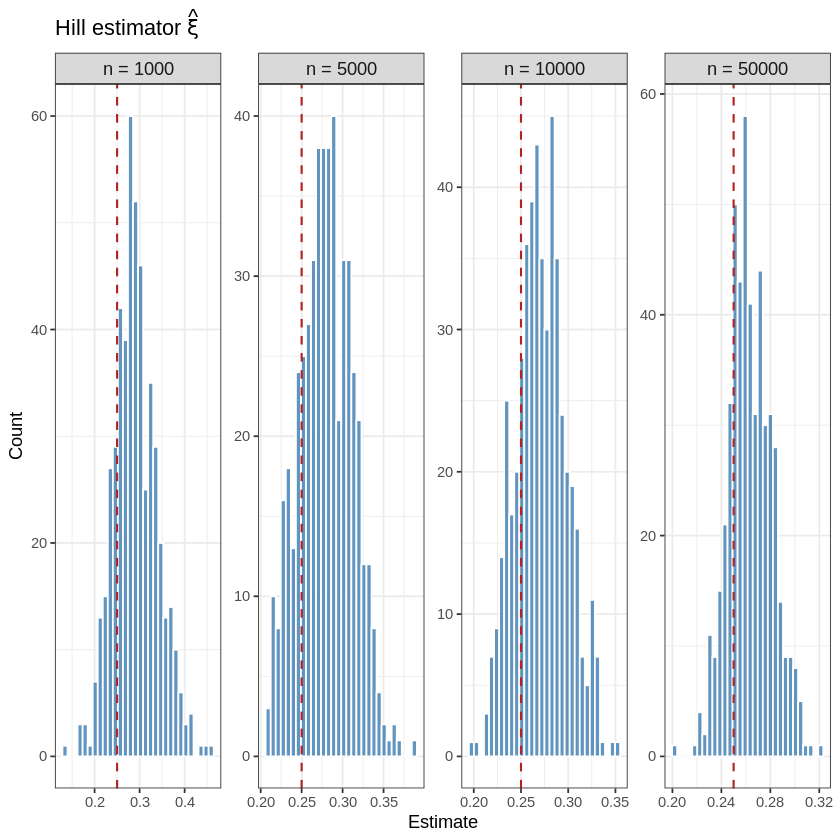

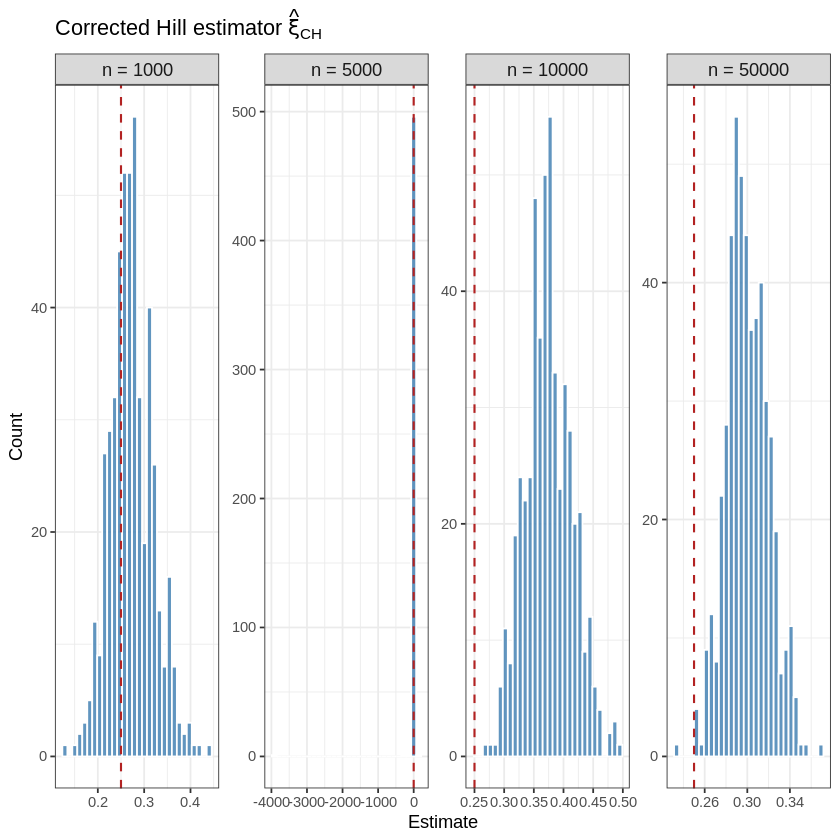

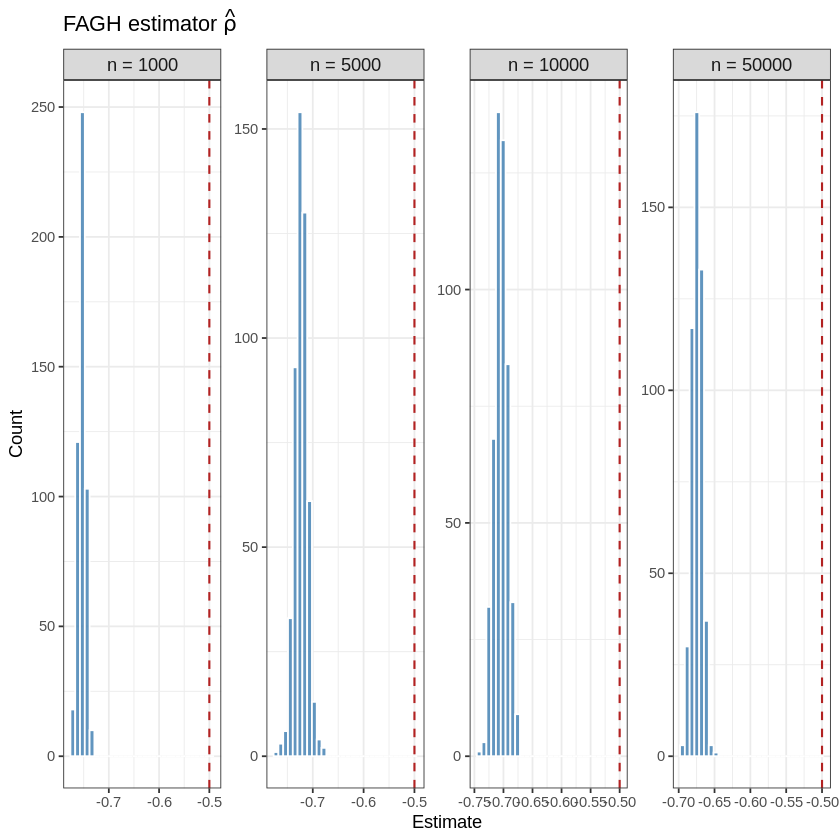

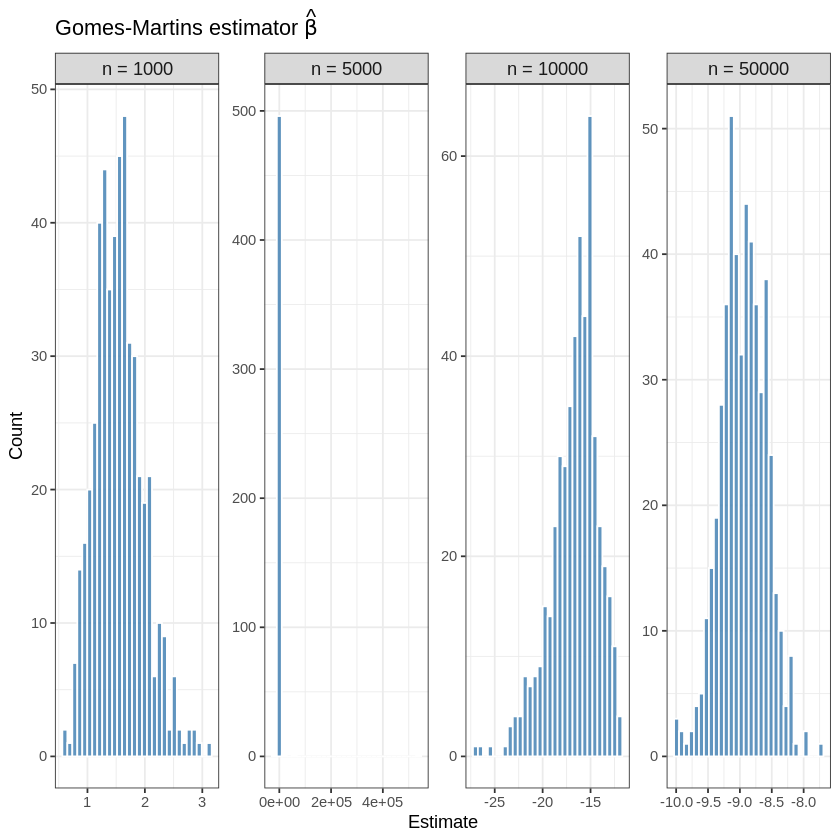

In [94]:
library(ggplot2)
library(dplyr)

# True values for the bivariate t with nu = 4
truth <- list(
    xi_hat_hill = 0.25,
    xi_hat_ch   = 0.25,
    rho_hat     = -0.5,
    beta_hat    = NA  # no canonical truth
)

# Nicer titles for each quantity
titles <- list(
    xi_hat_hill = expression("Hill estimator " * hat(xi)),
    xi_hat_ch   = expression("Corrected Hill estimator " * hat(xi)[CH]),
    rho_hat     = expression("FAGH estimator " * hat(rho)),
    beta_hat    = expression("Gomes-Martins estimator " * hat(beta))
)

# Function to build one plot for a given quantity
plot_quantity <- function(qty) {
    df <- diagnostics %>%
        mutate(n = factor(n, levels = sort(unique(n)),
                          labels = paste0("n = ", sort(unique(n)))))
    
    p <- ggplot(df, aes(x = .data[[qty]])) +
        geom_histogram(bins = 30, fill = "steelblue", 
                       colour = "white", alpha = 0.85) +
        facet_wrap(~ n, scales = "free", nrow = 1) +
        labs(x = "Estimate", y = "Count", title = titles[[qty]]) +
        theme_bw() +
        theme(
            strip.text = element_text(size = 11),
            panel.spacing = unit(0.5, "lines"),
            plot.title = element_text(size = 13)
        )
    
    # Add truth line if available
    if (!is.na(truth[[qty]])) {
        p <- p + geom_vline(xintercept = truth[[qty]],
                            colour = "firebrick", linetype = "dashed",
                            linewidth = 0.6)
    }
    
    return(p)
}

# Build and display each plot
p_hill <- plot_quantity("xi_hat_hill")
p_ch   <- plot_quantity("xi_hat_ch")
p_rho  <- plot_quantity("rho_hat")
p_beta <- plot_quantity("beta_hat")

# Display them (in a script, use print(); in Rmd or interactive, just type the name)
print(p_hill)
print(p_ch)
print(p_rho)
print(p_beta)

We also tried a bias correction where we expanded the region we took suprema and infima over, expanding it by the worst case bias. Here's the results, things sort of look ok! However, I have poor intuition as to why this should be working at all, or how to prove it. Our use of bias correction is also a little strange: we're basically just blowing up a region that would hopefully contain the true bias-corrected isolines using a heavy-handed second-order MRV approach, but I don't have a great understanding of how to use this object because this is not the typical way that bias correction is done.

In [6]:
somrv_conservative <- read_csv('/global/homes/j/jbbutler/isolines_uq/outputs/simulations/bias_correction/conservative_envelope_simulation.csv')
conservative <- somrv_conservative %>% group_by(n, theta) %>% summarize(r_true=mean(r_true), mean_lower=mean(r_lower), mean_upper=mean(r_upper))

Rows: 150000 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): dist
dbl (9): p, n, sim_id, theta, r_true, r_naive, r_lower, r_upper, xi_hat

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'n'. You can override using the `.groups`
argument.


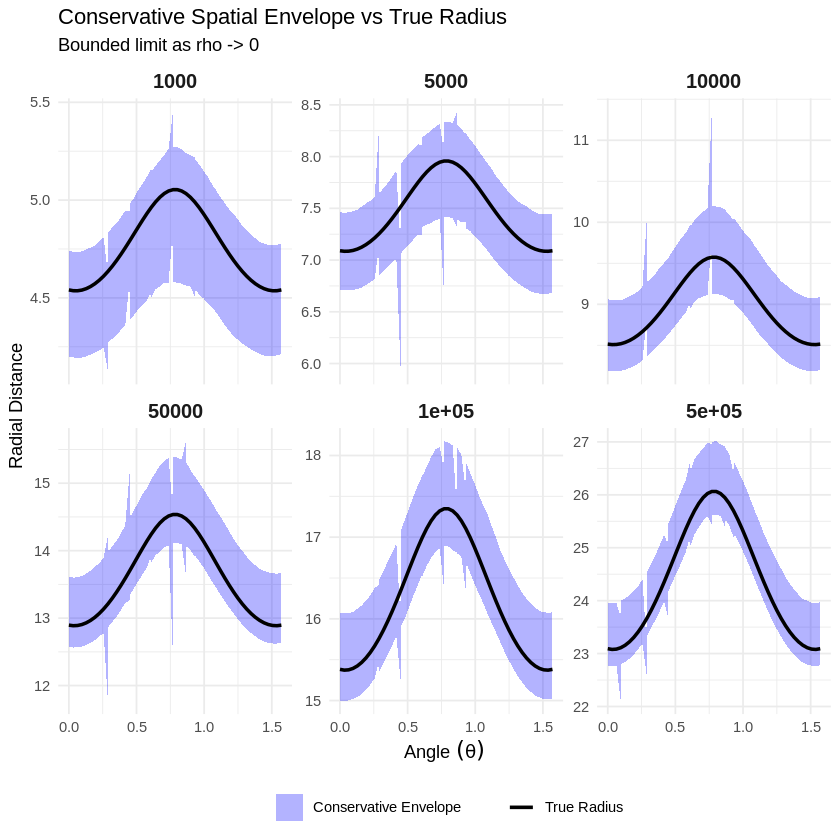

In [12]:
ggplot(conservative, aes(x = theta)) +
  # Draw the shaded conservative envelope
  geom_ribbon(aes(ymin = mean_lower, ymax = mean_upper, fill = "Conservative Envelope"), alpha = 0.3) +
  # Draw the true mathematical radius
  geom_line(aes(y = r_true, color = "True Radius"), linewidth = 1) +
  # Facet by sample size n to see the convergence
  facet_wrap(~ n, scales = "free_y") +
  # a
  scale_fill_manual(name = "", values = c("Conservative Envelope" = "blue")) +
  scale_color_manual(name = "", values = c("True Radius" = "black")) +
  labs(
    title = "Conservative Spatial Envelope vs True Radius",
    subtitle = "Bounded limit as rho -> 0",
    x = expression(Angle ~ (theta)),
    y = "Radial Distance"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    strip.text = element_text(size = 12, face = "bold")
  )

Mostly there! Now, let's do some simulations. In these simulations, we construct the region to take a supremum over by first getting our naive estimate of the isoline, the maximum second order bias correction, itself computed using estimates for $\xi$ and estimates for the bias of projecting from $q_{1}$ to $q_{2}$.

In [101]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_conservative_envelope.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.988,0.991,0
5000,0.01,0.980,0.983,0
10000,0.01,0.972,0.975,0
50000,0.01,0.930,0.933,0
1000,0.05,0.978,0.981,0
5000,0.05,0.960,0.963,0
10000,0.05,0.952,0.955,0
50000,0.05,0.894,0.898,0
1000,0.10,0.966,0.969,0


In [2]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_conservative_envelope_highergamma2.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.999,1.000,0
5000,0.01,0.999,1.000,0
10000,0.01,0.988,0.991,0
50000,0.01,0.966,0.969,0
1000,0.05,0.990,0.993,0
5000,0.05,0.996,0.999,0
10000,0.05,0.972,0.975,0
50000,0.05,0.950,0.953,0
1000,0.10,0.986,0.989,0


In [3]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_conservative_envelope_gamma1_0.4_gamma2_0.5.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.996,0.999,0
5000,0.01,0.970,0.973,0
10000,0.01,0.924,0.927,0
50000,0.01,0.758,0.762,0
1000,0.05,0.992,0.995,0
5000,0.05,0.944,0.947,0
10000,0.05,0.906,0.910,0
50000,0.05,0.692,0.696,0
1000,0.10,0.988,0.991,0


As a benchmark, let's compare against the naive procedure where there is no bias correction at all. Ok, so it does seem like the procedure does at least keep the bias afloat

In [3]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_nobc_unknownxi.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_estimate <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.824,0.828,0
5000,0.01,0.698,0.702,0
10000,0.01,0.682,0.686,0
50000,0.01,0.548,0.552,0
1000,0.05,0.712,0.716,0
5000,0.05,0.552,0.556,0
10000,0.05,0.572,0.576,0
50000,0.05,0.428,0.432,0
1000,0.10,0.646,0.650,0


## Bias Correction in the Probability Space

In [13]:
source('~/isolines_uq/scripts/R/confidence_regions/modules/utils.R')


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.8-40. For overview type 'help("mgcv-package")'.


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count




When trying to plug in second-order bias corrected estimators for the hill estimator and $\rho$, it seems like we don't do a great job of recovering the second order multivariate regular variation bias. It's in the wrong direction, and these estimators are incredibly unstable.. Taking it back to our observations, we were able to demonstrate that radial bias correction is crucial. However, I'm having a hard time understanding why. I think we don't have the full picture here..

Even if we address the radial bias issue, I'm not sure how to explain why this bias will be solving our problems? It was based on an intuition that the empirical survival function was working well because it was unbiased, but actually, I think it's because when we do our bootstrap, we are actually bootstrapping the difference between our survival function and the expected value of the survival function (effectively $p$). So, there's a bias then that needs to be added in, between the expected value of the survival function and the true survival function! When doing this, a term, unrelated to the variability of the process, pops out that can capture the bias.

For example, consider the following decomposition, letting $\pmb{x} \in \ell_{\pmb{X}}(p)$:

\begin{align}
\hat{\bar{F}}(\pmb{x}) - \bar{F}(\pmb{x}) = (\hat{\bar{F}}(\pmb{x})-\mathbb{E}[\hat{\bar{F}}(\pmb{x})]) + (\mathbb{E}[\hat{\bar{F}}(\pmb{x})]-\bar{F}(\pmb{x}))
\end{align}

The first term is the original term we had been considering all along. For the empirical survival function, it is simply equal to $p$ as that is an unbiased estimator. However, for our extreme survival function, it is not the case that this expectation will be equal to $p$. Why does this matter, though? When we go to the do the bootstrap to compute quantiles of the deviations of our estimator against $p$, we're effectively only taking care of this first term, completely ignoring the second! So, we want to consider this. When taking our quantiles, it'll end up being our original quantiles plus or minus some bias correction term, which, if we're being conservative, we can take to the the worst case bias over all angles, assuming a worst case $\rho \to 0$ if all we care about is being conservative.

### Experiment 0: Some Control Simulations

We first begin with some control simulations we can use to compare our results against.

#### Experiment 0.1

+ Simulation script: `exp0.1_ctrl.R`

Bivariate t distribution, but no bias correction, no log-space, and using fixed $\xi$ within the bootstrap loop (i.e. not re-estimated each time).

In [15]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/exp0.1_ctrl.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.904,0.908,0.004,453
5e+03,0.01,0.698,0.702,0.000,350
1e+04,0.01,0.672,0.676,0.000,337
5e+04,0.01,0.500,0.504,0.000,251
1e+05,0.01,0.506,0.510,0.000,254
1e+03,0.05,0.792,0.796,0.002,397
5e+03,0.05,0.584,0.588,0.000,293
1e+04,0.05,0.554,0.558,0.000,278
5e+04,0.05,0.378,0.382,0.000,190


In [28]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/extremal_hill_estim/no_bootstrap_xi/gamma1_0.5/bivt/n1e+05/simulation40.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)

In [1]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

ERROR: Error in ggplot(): could not find function "ggplot"


#### Experiment 0.2

+ Simulation script: `exp0.2_ctrl.R`

Bivariate t distribution, but no bias correction, no log-space, but re-estimating $\xi$ within the bootstrap loop.

In [38]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/exp0.2_ctrl.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.999,1.000,0.176,500
5e+03,0.01,0.994,0.997,0.000,498
1e+04,0.01,0.990,0.993,0.000,496
5e+04,0.01,0.996,0.999,0.000,499
1e+05,0.01,0.988,0.991,0.000,495
1e+03,0.05,0.984,0.987,0.038,493
5e+03,0.05,0.966,0.969,0.000,484
1e+04,0.05,0.978,0.981,0.000,490
5e+04,0.05,0.964,0.967,0.000,483


In [39]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/extremal_hill_estim/bootstrap_xi/gamma1_0.5/bivt/n1e+05/simulation40.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)


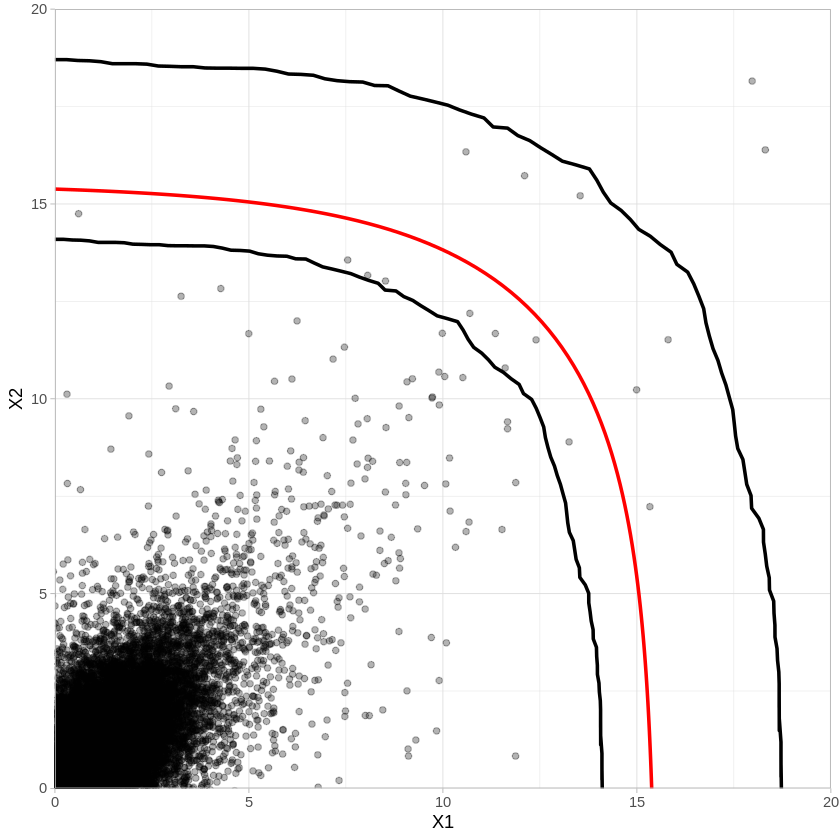

In [40]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

### Experiment 1: Most Heavy-Handed

Implementing the bias correction above, except our $c_{\alpha}^{+}$, $c_{\alpha}^{-}$ in our construction end up being the original ones we've used all along, plus or minus some worst case bias term that represents the worst case absolute bias computed from second order MRV, taken across all angles $\theta$ with $\rho \to 0$. Pretty heavy-handed, but maybe we can relax some of this.

In [57]:
library(ggplot2)
library(readr)
library(dplyr)

In [138]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_probability_BC_gamma1_0.5_gamma2_0.67.csv'

In [139]:
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,0.01,0.996,0.999,0.910
5000,0.01,0.994,0.997,0.776
10000,0.01,0.988,0.991,0.682
50000,0.01,0.984,0.987,0.302
1000,0.05,0.996,0.999,0.870
5000,0.05,0.990,0.993,0.724
10000,0.05,0.986,0.989,0.628
50000,0.05,0.982,0.985,0.248
1000,0.10,0.996,0.999,0.844


In [140]:
res %>% group_by(n, p, alpha) %>% summarize(mean(c_plus_adj), mean(c_minus_adj), mean(beta_max), mean(c_plus_raw), mean(c_minus_raw)) %>% ungroup() %>% filter(alpha==0.05)

`summarise()` has grouped output by 'n', 'p'. You can override using the
`.groups` argument.


n,p,alpha,mean(c_plus_adj),mean(c_minus_adj),mean(beta_max),mean(c_plus_raw),mean(c_minus_raw)
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,5e-03,0.05,1.080036e-02,-7.847169e-03,5.083576e-03,5.716783e-03,-2.763593e-03
5000,1e-03,0.05,1.493391e-03,-1.283413e-03,9.268270e-04,5.665636e-04,-3.565857e-04
10000,5e-04,0.05,6.459166e-04,-5.792650e-04,4.309894e-04,2.149272e-04,-1.482756e-04
50000,1e-04,0.05,9.100005e-05,-8.571822e-05,6.619686e-05,2.480319e-05,-1.952136e-05


Let's take a look at one of these tubes.

### Group 2: Working in the Log-Space

So, the danger of adding a bias term that is not dependent on the quantiles of the suprema/infima is that now, we can have the case where we are so biased that our tubes are actually unbounded. So, not only are we conservative now, but conservative in the worst way. Of course, this could be adjusted by not being so heavy-handed with our bias correction as in the above simulation, but whenever adding a bias in this way, we run the risk of having these confidence tubes. It might be better to think of this bias correction as as multiplicative rather than additive (which makes sense too given the small probabilities we are dealing with..), especially since the limit relation for SOMRV is written in multiplicative form. This section explores an approach similar to the above but everything is performed in the log-space now so that our tube bounds end up being multiplicative factors of $p$ as opposed to additive.

### Experiment 2.1: Most-Heavy Handed Bias

The bias is a supremum of the absolute value over all angles, and so applied uniformly to the upper and lower confidence tube.

In [141]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_fractional_log_BC_gamma1_0.5_gamma2_0.67.csv'

In [142]:
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1000,0.01,0.999,1.000,0,500
5000,0.01,0.999,1.000,0,500
10000,0.01,0.999,1.000,0,500
50000,0.01,0.999,1.000,0,500
1000,0.05,0.999,1.000,0,500
5000,0.05,0.996,0.999,0,499
10000,0.05,0.999,1.000,0,500
50000,0.05,0.994,0.997,0,498
1000,0.10,0.999,1.000,0,500


In [143]:
res %>% group_by(n, p, alpha) %>% summarize(mean(c_plus_adj), mean(c_minus_adj)) %>% ungroup() %>% filter(alpha==0.05)

`summarise()` has grouped output by 'n', 'p'. You can override using the
`.groups` argument.


n,p,alpha,mean(c_plus_adj),mean(c_minus_adj)
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000,5e-03,0.05,0.0296358396,-3.992632e-03
5000,1e-03,0.05,0.0033463295,-7.168019e-04
10000,5e-04,0.05,0.0013348041,-3.347546e-04
50000,1e-04,0.05,0.0001507636,-5.645321e-05


In [144]:
source('~/isolines_uq/scripts/R/confidence_regions/modules/distributionIsolines.R')

In [104]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal_logprobability_bias_correction/gamma1_0.5_gamma2_0.67/bivt/n10000/simulation60.RData'
tube_obj <- readRDS(load_path)

In [105]:
tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.01']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.01']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)

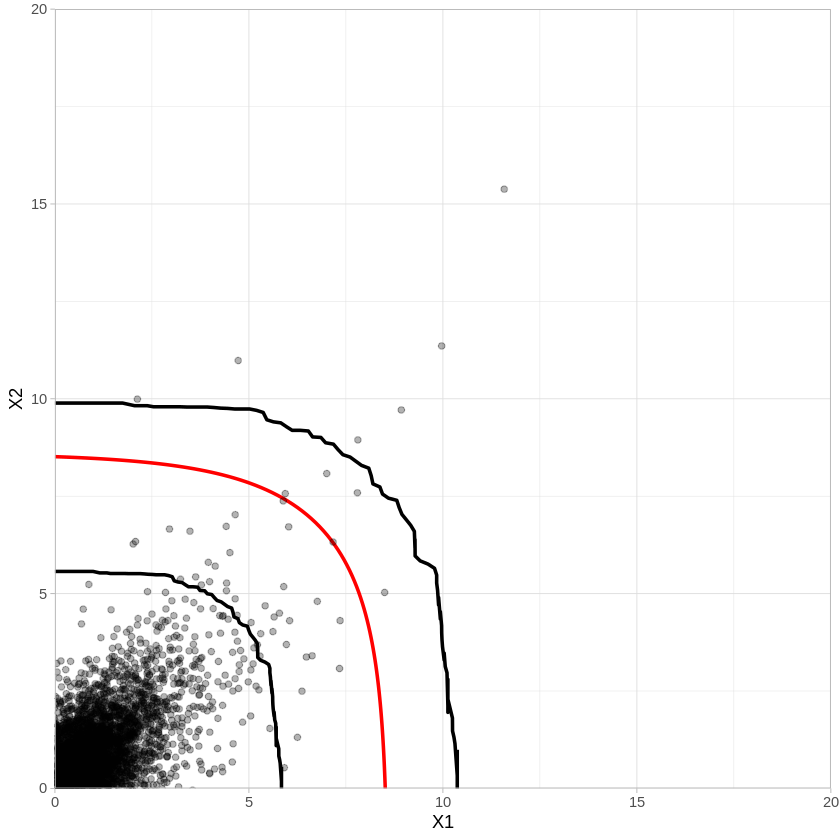

In [106]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

### Experiment 2.2: Less-Heavy Handed


#### Experiment 2.2.0: Fixed, oracle $\xi$

This is with a bias-correction.

In [17]:
path <- '~/isolines_uq/outputs/simulations/extremal/0.0.1.2_bivt4_oraclexi_gamma1_0.5_gamma2_0.67.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(is_unbounded)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.999,1.000,0,500
5e+03,0.01,0.996,0.999,0,499
1e+04,0.01,0.994,0.997,0,498
5e+04,0.01,0.990,0.993,0,496
1e+05,0.01,0.986,0.989,0,494
1e+03,0.05,0.996,0.999,0,499
5e+03,0.05,0.994,0.997,0,498
1e+04,0.05,0.990,0.993,0,496
5e+04,0.05,0.988,0.991,0,495


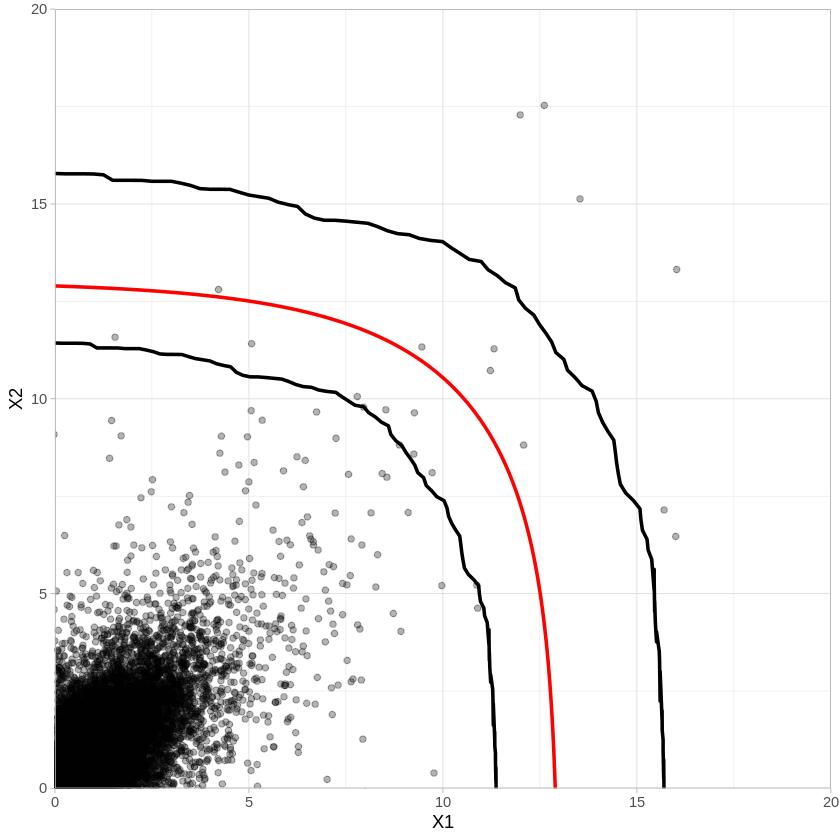

In [22]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/0.0.1.2_bivt4_gamma1_0.5_oraclexi/bivt/n50000/simulation60.RData'
tube_obj <- readRDS(load_path)
tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)

ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

This is without the bias correction.

In [18]:
path <- '~/isolines_uq/outputs/simulations/extremal/0.0.1.0_bivt4_gamma1_0.5_oraclexi.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(is_unbounded)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.624,0.628,0,313
5e+03,0.01,0.366,0.370,0,184
1e+04,0.01,0.296,0.300,0,149
5e+04,0.01,0.136,0.140,0,69
1e+05,0.01,0.112,0.116,0,57
1e+03,0.05,0.412,0.416,0,207
5e+03,0.05,0.202,0.206,0,102
1e+04,0.05,0.122,0.126,0,62
5e+04,0.05,0.057,0.060,0,29


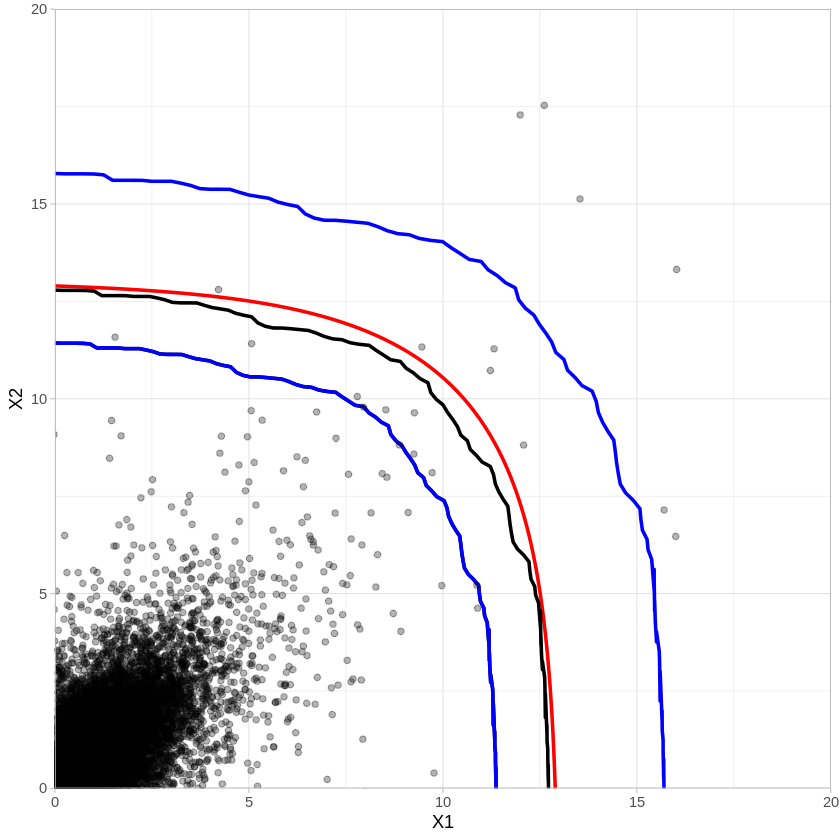

In [25]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/0.0.1.2_bivt4_gamma1_0.5_oraclexi/bivt/n50000/simulation60.RData'
tube_obj <- readRDS(load_path)
tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_lower_bc <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper_bc <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)

ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) +
    geom_line(data=tube_upper_bc, aes(x=X1, y=X2), linewidth=1, color='blue') + 
    geom_line(data=tube_lower_bc, aes(x=X1, y=X2), linewidth=1, color='blue') +
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

#### Experiment 2.2.1: Fixed Bootstrap $\xi$

Let's peel it back for a second. We are assuming a sup absolute bias, so positive bias also contributes to making the negative bias correction larger. Let's split it up into one bias correction for the upper tube, and one for the lower tube.

In [145]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_fractional_log_asymmetric_BC_gamma1_0.5_gamma2_0.67.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.996,0.999,0,499
5e+03,0.01,0.994,0.997,0,498
1e+04,0.01,0.984,0.987,0,493
5e+04,0.01,0.954,0.957,0,478
1e+05,0.01,0.932,0.935,0,467
1e+03,0.05,0.990,0.993,0,496
5e+03,0.05,0.986,0.989,0,494
1e+04,0.05,0.962,0.965,0,482
5e+04,0.05,0.936,0.939,0,469


In [152]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/extremal_logprobability_bias_correction/exp2.2.1/gamma1_0.5_gamma2_0.67/bivt/n1e+05/simulation40.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)


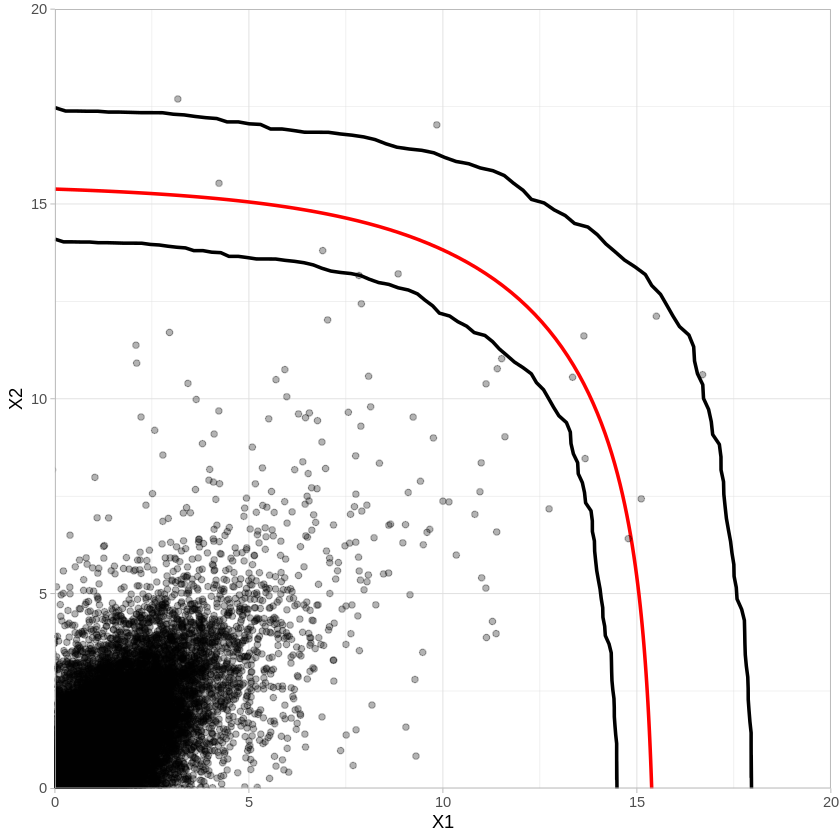

In [153]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

#### Control

Here, we'll evaluate the coverage on the simulations with no bias correction at all. Thus, this will show us the coverage behavior when using the log construction, but keeping the same fitted $\hat{\xi}$ in the bootstrap loop.

In [10]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_exp2.2.1_ctrl.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_raw <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.818,0.822,0,410
5e+03,0.01,0.696,0.700,0,349
1e+04,0.01,0.624,0.628,0,313
5e+04,0.01,0.498,0.502,0,250
1e+05,0.01,0.458,0.462,0,230
1e+03,0.05,0.662,0.666,0,332
5e+03,0.05,0.558,0.562,0,280
1e+04,0.05,0.488,0.492,0,245
5e+04,0.05,0.378,0.382,0,190


In [12]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/extremal_logprobability_bias_correction/exp2.2.1/gamma1_0.5_gamma2_0.67/bivt/n1e+05/simulation40.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)


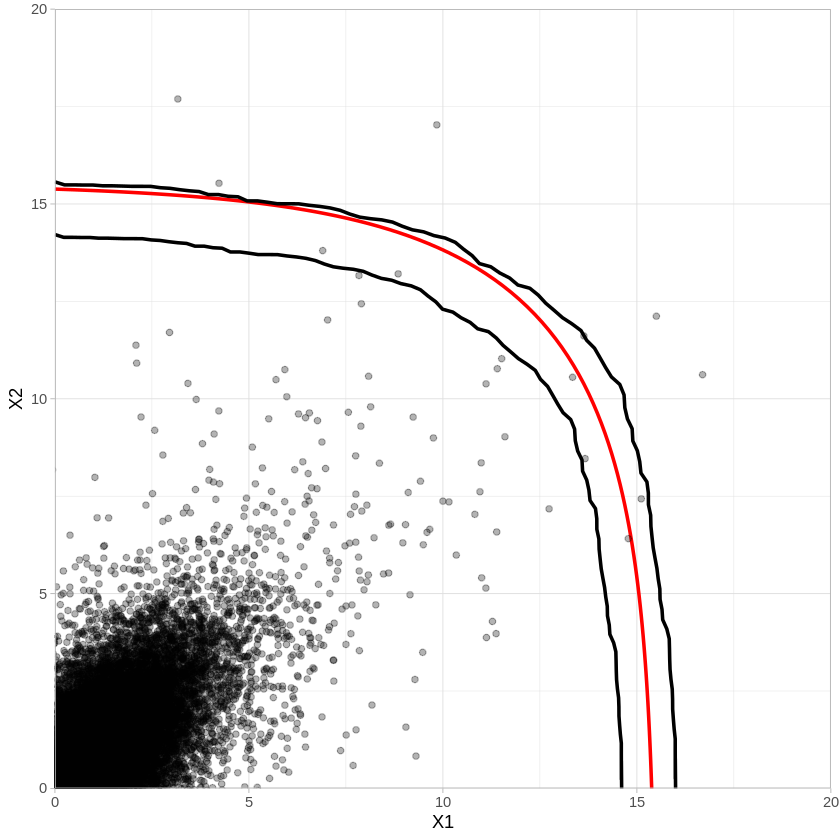

In [13]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,20), ylim=c(0,20), expand=F) + theme_light()

#### Experiment 2.2.2: Bootstrap $\xi$

In the other simulations, we assume that $\xi$ is fixed quantity in the bootstrap: for the purposes of the bootstrap loop, the same $\xi$ is used, even on the same draw of bootstrap data. However, if you have a different draw of data, $\xi$ should be changing!

In [50]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_fractional_log_asymmetric_BC_gamma1_0.5_gamma2_0.67_2.2.2.csv'

In [51]:
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.999,1.000,0,500
5e+03,0.01,0.999,1.000,0,500
1e+04,0.01,0.999,1.000,0,500
5e+04,0.01,0.999,1.000,0,500
1e+05,0.01,0.999,1.000,0,500
1e+03,0.05,0.999,1.000,0,500
5e+03,0.05,0.999,1.000,0,500
1e+04,0.05,0.999,1.000,0,500
5e+04,0.05,0.996,0.999,0,499


In [46]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal_logprobability_bias_correction/exp2.2.2/gamma1_0.5_gamma2_0.67/bivt/n1e+05/simulation10.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)


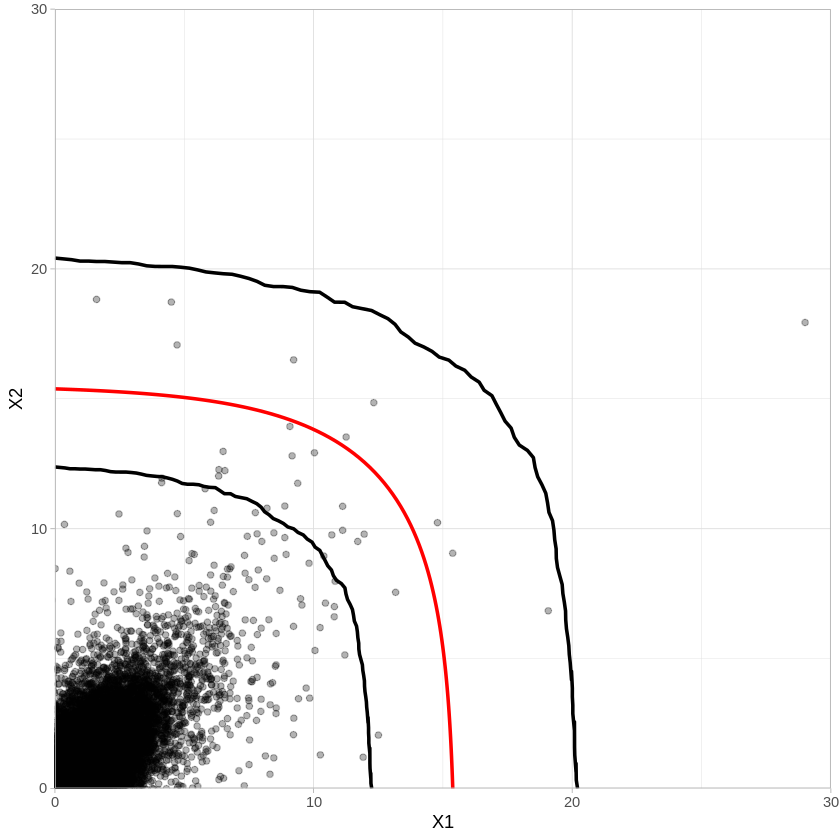

In [47]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,30), ylim=c(0,30), expand=F) + theme_light()

Overcovered, but this makes more sense to me!

#### Control

Let's use the unadjusted values $c$ values instead of the adjusted ones. So, this will show the method's performance using the log construction and with re-estimating $\xi$ within the bootstrap loop.

In [17]:
path <- '~/isolines_uq/outputs/simulations/bias_correction/extremal_coverage_exp2.2.2_ctrl.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_raw <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.996,0.999,0,499
5e+03,0.01,0.988,0.991,0,495
1e+04,0.01,0.984,0.987,0,493
5e+04,0.01,0.994,0.997,0,498
1e+05,0.01,0.986,0.989,0,494
1e+03,0.05,0.962,0.965,0,482
5e+03,0.05,0.948,0.951,0,475
1e+04,0.05,0.938,0.941,0,470
5e+04,0.05,0.954,0.957,0,478


In [5]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal_logprobability_bias_correction/exp2.2.2/gamma1_0.5_gamma2_0.67/bivt/n1e+05/simulation10.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)

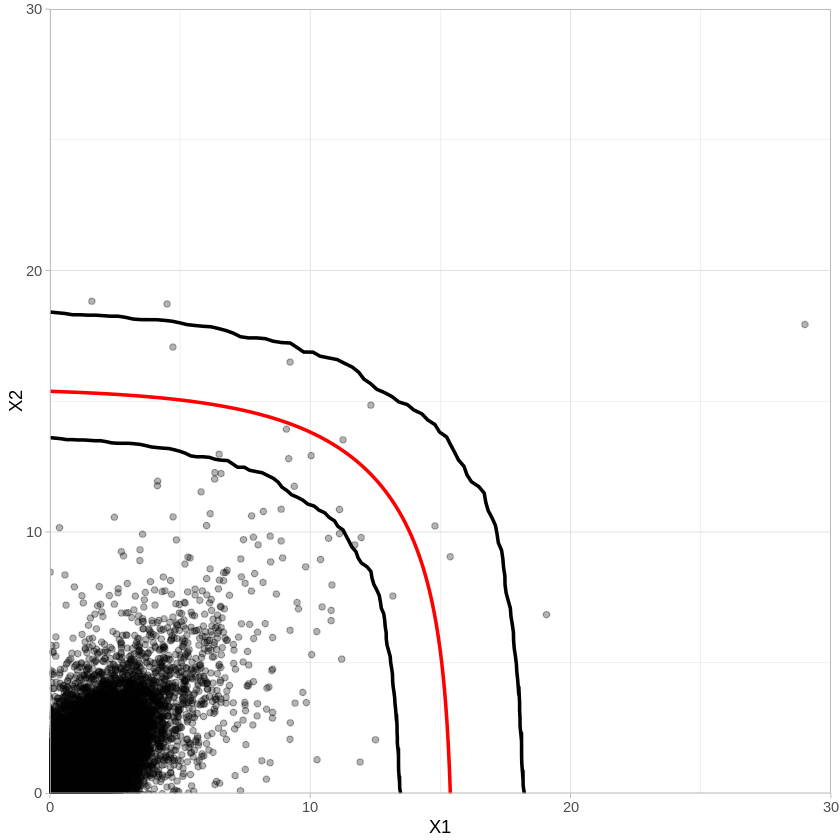

In [6]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,30), ylim=c(0,30), expand=F) + theme_light()

What if we tried a distribution that intuitively converges more slowly? So, bivariate t with log gamma marginals.

In [3]:
path <- '~/isolines_uq/outputs/simulations/extremal/0.0.1.2_bivt4copula_loggammamargins_gamma1_0.5_gamma2_0.67_bootxi.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.999,1.000,0,500
5e+03,0.01,0.999,1.000,0,500
1e+04,0.01,0.999,1.000,0,500
5e+04,0.01,0.999,1.000,0,500
1e+05,0.01,0.999,1.000,0,500
1e+03,0.05,0.996,0.999,0,499
5e+03,0.05,0.999,1.000,0,500
1e+04,0.05,0.996,0.999,0,499
5e+04,0.05,0.996,0.999,0,499


In [4]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/0.0.1.2_bivt4copula_loggammamargins_gamma1_0.5_gamma2_0.67_bootxi/t4copula_loggamma/n1e+05/simulation10.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

bivt_isoline <- drawIsoline('bivt', 100, c(30,30), c(0,0), tube_obj$p)
U1 <- pt(bivt_isoline[, 1], df = 4)
U2 <- pt(bivt_isoline[, 2], df = 4)
X1 <- exp(qgamma(U1, shape = 2, rate = 4))
X2 <- exp(qgamma(U2, shape = 2, rate = 4))
isoline <- data.frame(X1 = X1, X2 = X2)

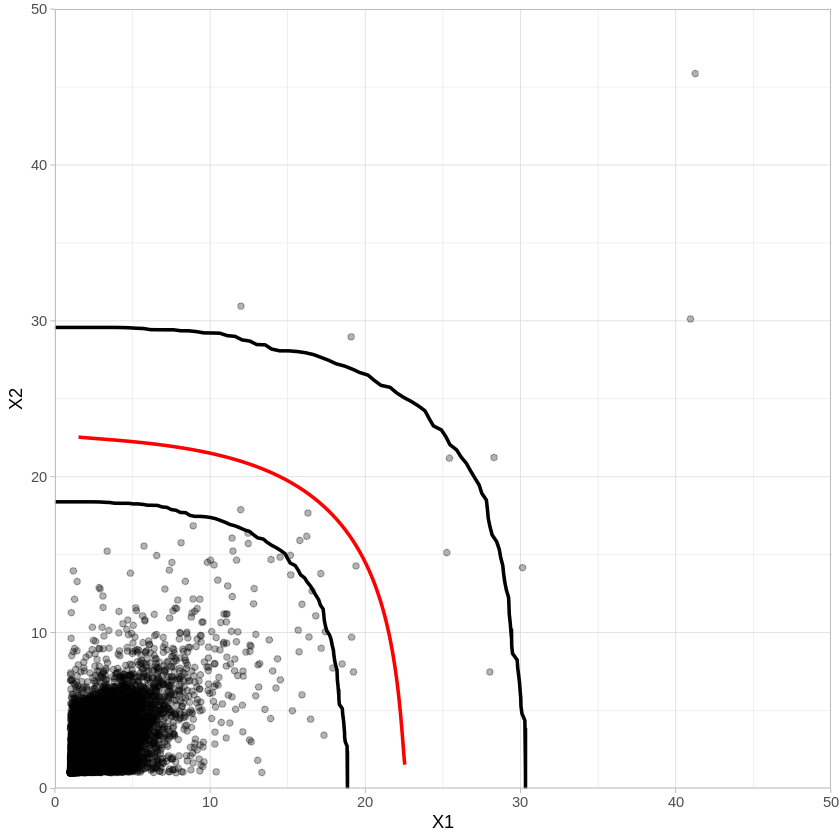

In [6]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,50), ylim=c(0,50), expand=F) + theme_light()

In [12]:
path <- '~/isolines_uq/outputs/simulations/extremal/0.0.1.0_bivt4copula_loggammamargins_gamma1_0.5_bootxi.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(is_unbounded), mean_xi_hat=mean(xi_hat)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered, mean_xi_hat)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered,mean_xi_hat
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1e+03,0.01,0.996,0.999,0,499,0.2833868
5e+03,0.01,0.990,0.993,0,496,0.2811538
1e+04,0.01,0.980,0.983,0,491,0.2801455
5e+04,0.01,0.992,0.995,0,497,0.2747476
1e+05,0.01,0.990,0.993,0,496,0.2746210
1e+03,0.05,0.966,0.969,0,484,0.2833868
5e+03,0.05,0.970,0.973,0,486,0.2811538
1e+04,0.05,0.942,0.945,0,472,0.2801455
5e+04,0.05,0.956,0.959,0,479,0.2747476


#### Experiment 2.2.3: Bootstrap $\xi$, asymptotic independence

In [3]:
path <- '~/isolines_uq/outputs/simulations/extremal/1.0.1.2_gausscopula_t4margs_gamma1_0.5_gamma2_0.67_bootxi_cooleysmooth.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_adj <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.999,1.000,0,500
5e+03,0.01,0.999,1.000,0,500
1e+04,0.01,0.999,1.000,0,500
5e+04,0.01,0.999,1.000,0,500
1e+05,0.01,0.999,1.000,0,500
1e+03,0.05,0.996,0.999,0,499
5e+03,0.05,0.999,1.000,0,500
1e+04,0.05,0.999,1.000,0,500
5e+04,0.05,0.996,0.999,0,499


In [5]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/1.0.1.2_gausscopula_t4margs_gamma1_0.5_gamma2_0.67_bootxi_cooleysmooth/gauss_copula_t4/n1e+05/simulation90.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

angular_pad <- 0.1
gauss_isoline <- drawIsoline('bivgauss', 50, c(200,200), c(0,0), tube_obj$p, angular_extents=c(angular_pad, (pi/2)-angular_pad))
copula_isoline <- data.frame(X1=pnorm(gauss_isoline[,1]), X2=pnorm(gauss_isoline[,2]))
isoline <- data.frame(X1=qt(copula_isoline[,1], df=4), X2=qt(copula_isoline[,2], df=4))

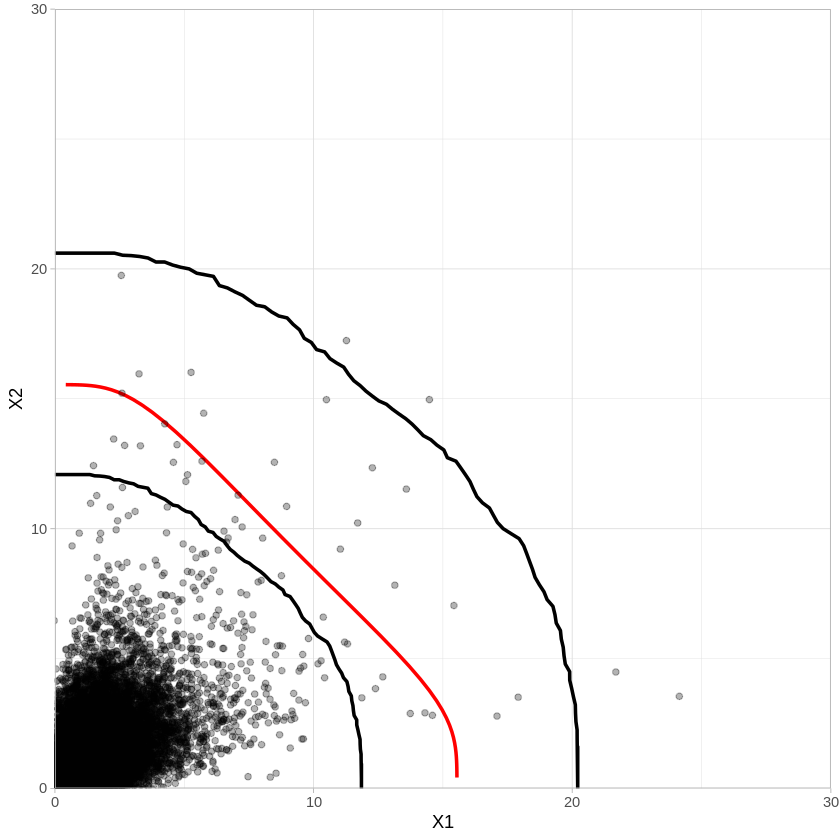

In [6]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,30), ylim=c(0,30), expand=F) + theme_light()

#### Control

Let's use the unadjusted values $c$ values instead of the adjusted ones.

In [13]:
path <- '~/isolines_uq/outputs/simulations/extremal/1.0.1.0_gausscopula_t4margs_gamma0.5_bootxi_cooleysmooth.csv'
res <- read_csv(path, show_col_types=FALSE)
aggRes <- res %>% group_by(dist, n, alpha) %>% summarize(covrate=mean(is_covered), n_covered=sum(is_covered), num_covered=sum(is_covered), unbounded_rate=mean(c_minus_raw <= -p)) %>% arrange(alpha)
aggRes <- addCIs(0.95, aggRes) %>% ungroup()
aggRes %>% select(n, alpha, confint_lb, confint_ub, unbounded_rate, n_covered)

`summarise()` has grouped output by 'dist', 'n'. You can override using the
`.groups` argument.


n,alpha,confint_lb,confint_ub,unbounded_rate,n_covered
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1e+03,0.01,0.990,0.993,0,496
5e+03,0.01,0.988,0.991,0,495
1e+04,0.01,0.992,0.995,0,497
5e+04,0.01,0.980,0.983,0,491
1e+05,0.01,0.968,0.971,0,485
1e+03,0.05,0.972,0.975,0,487
5e+03,0.05,0.950,0.953,0,476
1e+04,0.05,0.950,0.953,0,476
5e+04,0.05,0.930,0.933,0,466


In [16]:
load_path <- '/pscratch/sd/j/jbbutler/isolines/simulations/extremal/1.0.1.2_gausscopula_t4margs_gamma1_0.5_gamma2_0.67_bootxi_cooleysmooth/gauss_copula_t4/n1e+05/simulation90.RData'
tube_obj <- readRDS(load_path)

tube_lower <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_plus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

tube_upper <- drawExtremeIsoline(dat=tube_obj$dat, 
                                  p=tube_obj$p+tube_obj$raw_c_minus_estimates[['0.05']],
                                  n_coords=100,
                                  grid_lbs=c(0,0), 
                                  gamma=tube_obj$gamma1,
                                  xi=tube_obj$xi_hat)

angular_pad <- 0.1
gauss_isoline <- drawIsoline('bivgauss', 50, c(200,200), c(0,0), tube_obj$p, angular_extents=c(angular_pad, (pi/2)-angular_pad))
copula_isoline <- data.frame(X1=pnorm(gauss_isoline[,1]), X2=pnorm(gauss_isoline[,2]))
isoline <- data.frame(X1=qt(copula_isoline[,1], df=4), X2=qt(copula_isoline[,2], df=4))

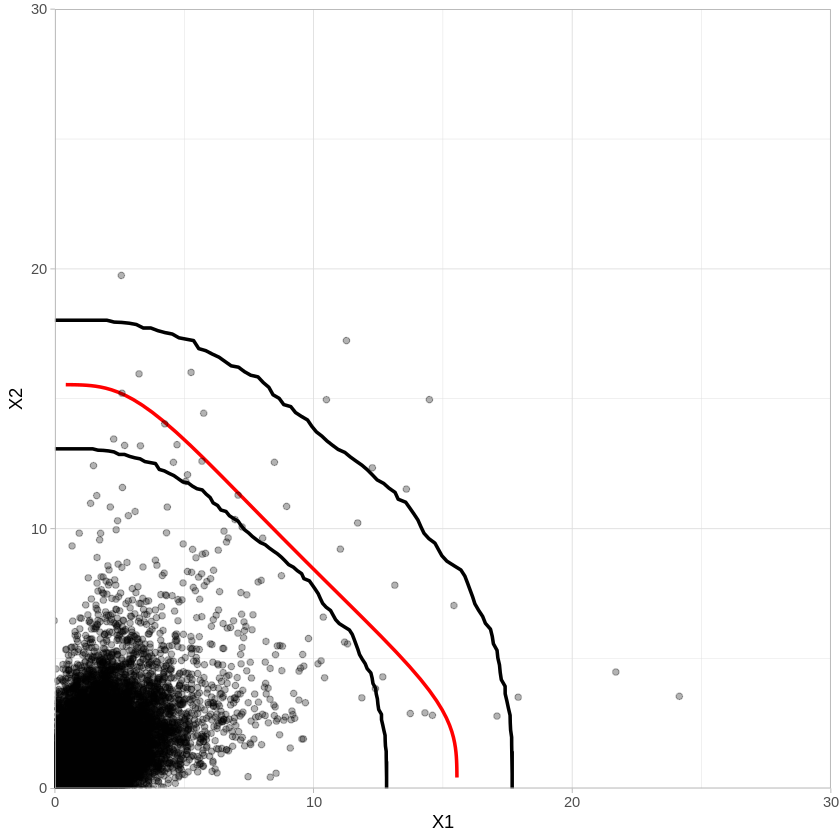

In [17]:
ggplot() + geom_line(data=isoline, aes(x=X1, y=X2), color='red', linewidth=1) + 
    geom_line(data=tube_upper, aes(x=X1, y=X2), linewidth=1) + 
    geom_line(data=tube_lower, aes(x=X1, y=X2), linewidth=1) + 
    geom_point(data=tube_obj$dat, aes(x=X1, y=X2), alpha=0.3) + coord_cartesian(xlim=c(0,30), ylim=c(0,30), expand=F) + theme_light()